In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
from Data_cleaning_utils import perform_data_cleaning
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [3]:
df = pd.read_csv(r"C:\Users\User\delivery-time-prediction\data\raw\swiggy.csv")
df.info()
cleaned_df = perform_data_cleaning(df)
cleaned_df = cleaned_df.dropna()
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [4]:
numerical_cols = cleaned_df.select_dtypes(include=['float', 'int']).columns
categorical_cols = cleaned_df.select_dtypes(include=['object']).columns

# EDA Function Template

In [5]:
#Univariate_numerical

def uni_num(cols):

        # Distribution and Boxplots

        fig = plt.figure(figsize=(15,8))

        grid = GridSpec(2,2,figure = fig)

        ax1 = fig.add_subplot(grid[0,0])
        ax2 = fig.add_subplot(grid[0,1])
        ax3 = fig.add_subplot(grid[1,:])


        sns.histplot(cleaned_df[cols],kde=True,bins='auto',ax=ax3)
        ax3.grid(False)
        ax3.set_title('Histogram')

        sns.boxplot(x=cleaned_df[cols],ax=ax2)
        ax2.grid(False)
        ax2.set_title('Boxplot')

        sns.kdeplot(x=cleaned_df[cols],ax=ax1)
        ax1.grid(False)
        ax1.set_title('Kdensity')

        plt.tight_layout()
        

        # Descriptive Statistics
        print(cleaned_df[cols].describe(), "\n")

        # Normality Test and Skewness
        print(f"Skewness : {cleaned_df[cols].skew()}", "\n")

        print(f"p_value : {stats.shapiro(cleaned_df[cols]).pvalue:.4f}", "\n")
        if stats.shapiro(cleaned_df[cols]).pvalue < 0.05:
            print("Data is not normally distributed" , "\n")
        else:
            print("Data is normally distributed" , "\n")

        # Outliers test and Kurtosis
        q1 = np.percentile(cleaned_df[cols], 25)
        q3 = np.percentile(cleaned_df[cols], 75)
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        if (cleaned_df[cols] < lower_bound).any() or (cleaned_df[cols] > upper_bound).any():
            print("Data has outliers" , "\n")
        else:
            print("Data does not have outliers" , "\n")
        
        print(f"Kurtosis : {cleaned_df[cols].kurt()}")


# Univariate Categorical

def uni_cat(cols):

    fig, axes = plt.subplots(1,2,figsize=(15,8))

    cleaned_df[cols].value_counts().plot(kind='bar',color='skyblue',ax=axes[0])
    axes[0].grid(False)
    axes[0].set_title('Barplot')

    cleaned_df[cols].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=axes[1])
    axes[1].grid(False)
    axes[1].set_title('Piechart')

    plt.tight_layout()

    print(f"There are {cleaned_df[cols].nunique()} unique values in {cols} column", "\n")

    { print(f"There are {((cleaned_df[cols].isnull().sum()) / 
    len(cleaned_df[cols])).round(2)*100}% missing values in {cols} column", "\n") }

    print(cleaned_df[cols].value_counts(normalize=True), "\n")


# Bivariate Numerical Categorical

def num_cat(num_col,cat_col):
    # visualization

    fig , (ax1, ax2) = plt.subplots(2,2,figsize=(15,8))

    sns.barplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],palette="pastel" ,estimator=np.median,ax=ax1[0])
    ax1[0].grid(False)

    sns.boxplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],palette="pastel" ,ax=ax1[1])
    ax1[1].grid(False)

    sns.violinplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],palette="pastel" ,ax=ax2[0])
    ax2[0].grid(False)

    sns.stripplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],palette="pastel", alpha=0.5, jitter=0.2,ax=ax2[1])
    ax2[1].grid(False)

    # Mean Difference Test

    if cleaned_df[cat_col].nunique() >2:

        test_df = cleaned_df.dropna()
        groups = [test_df[num_col][test_df[cat_col] == category] for category in test_df[cat_col].unique()]

        f_stat,p_value = stats.f_oneway(*groups)

        print(f"p_value : {p_value:.4f}", "\n")

        if p_value < 0.05:
            print("There is a significant difference between the means of the groups", "\n")
        else:
            print("There is no significant difference between the means of the groups", "\n")
    else:
        
        test_df = cleaned_df.dropna()
        groups = [test_df[num_col][test_df[cat_col] == category] for category in test_df[cat_col].unique()]

        f_stat,p_value = stats.ttest_ind(*groups)

        print(f"p_value : {p_value:.4f}", "\n")

        if p_value < 0.05:
                print("There is a significant difference between the means of the groups", "\n")
        else:
                print("There is no significant difference between the means of the groups", "\n")

# Categorical Categorical

def cat_cat(cols1,cols2):
    fig = px.imshow(pd.crosstab(cleaned_df[cols1],cleaned_df[cols2]),
                    text_auto=True, color_continuous_scale='blues', aspect="auto")
    fig.show()

    contingency_table = pd.crosstab(cleaned_df[cols1],cleaned_df[cols2])

    ch2_stat,p_value,_,_ = stats.chi2_contingency(contingency_table)
    print(p_value)

    if p_value < 0.05:
        print(f"There is a significant association between {cols1} and {cols2}", "\n")
    else:
        print(f"There is no significant association between {cols1} and {cols2}", "\n")

# Multivariate Analysis

def multivariate_analysis(num_col,cat_col1,cat_col2):

    fig , (ax1, ax2) = plt.subplots(2,2,figsize=(15,8))

    sns.barplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col],hue=cleaned_df[cat_col2], palette="pastel" ,estimator=np.median,ax=ax1[0])
    ax1[0].grid(False)

    sns.boxplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col],hue=cleaned_df[cat_col2],palette="pastel" ,gap=0.1, ax=ax1[1])
    ax1[1].grid(False)

    sns.violinplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col], hue=cleaned_df[cat_col2],palette="pastel" ,gap=0.1 ,ax=ax2[0])
    ax2[0].grid(False)

    sns.stripplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col],hue=cleaned_df[cat_col2], palette="pastel" ,dodge=True ,alpha=0.5, jitter=0.2,ax=ax2[1])
    ax2[1].grid(False)

    plt.tight_layout()

# Column Wise Analysis with Dependant variable Delivery Time

In [6]:
cleaned_df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_lat', 'restaurant_long',
       'delivery_lat', 'delivery_long', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle_type',
       'multiple_deliveries', 'festival', 'city_type', 'time', 'city_name',
       'distance_km', 'day', 'month', 'day_of_week', 'is_weekend',
       'pickup_time', 'order_time_hour', 'time_of_day'],
      dtype='object')

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64 

Skewness : -0.014541859592086084 

p_value : nan 

Data is normally distributed 

Data does not have outliers 

Kurtosis : -1.2085996871450444


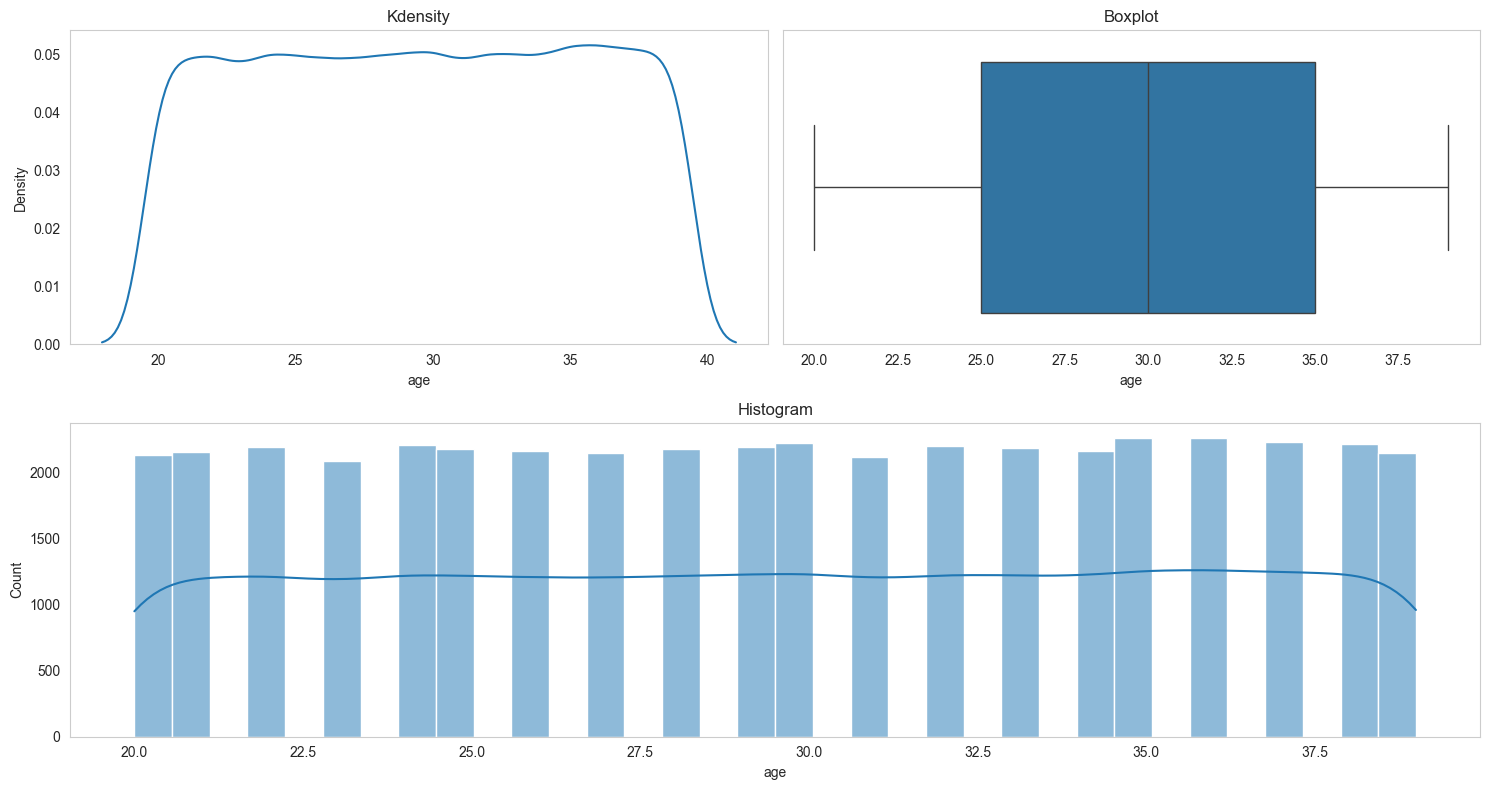

In [7]:
uni_num('age')

<Axes: xlabel='age', ylabel='time'>

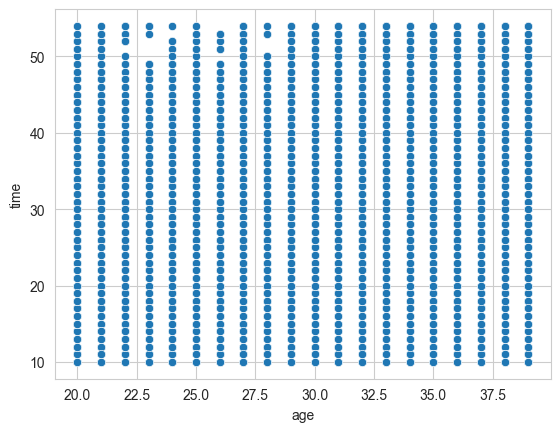

In [8]:
sns.scatterplot(x=cleaned_df['age'],y=cleaned_df['time'])

Rider's Age is Uniformly distributed, it does not have any visible impact on the delivery time

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64 

Skewness : -1.7931177887882856 

p_value : nan 

Data is normally distributed 

Data does not have outliers 

Kurtosis : 5.137552745564457


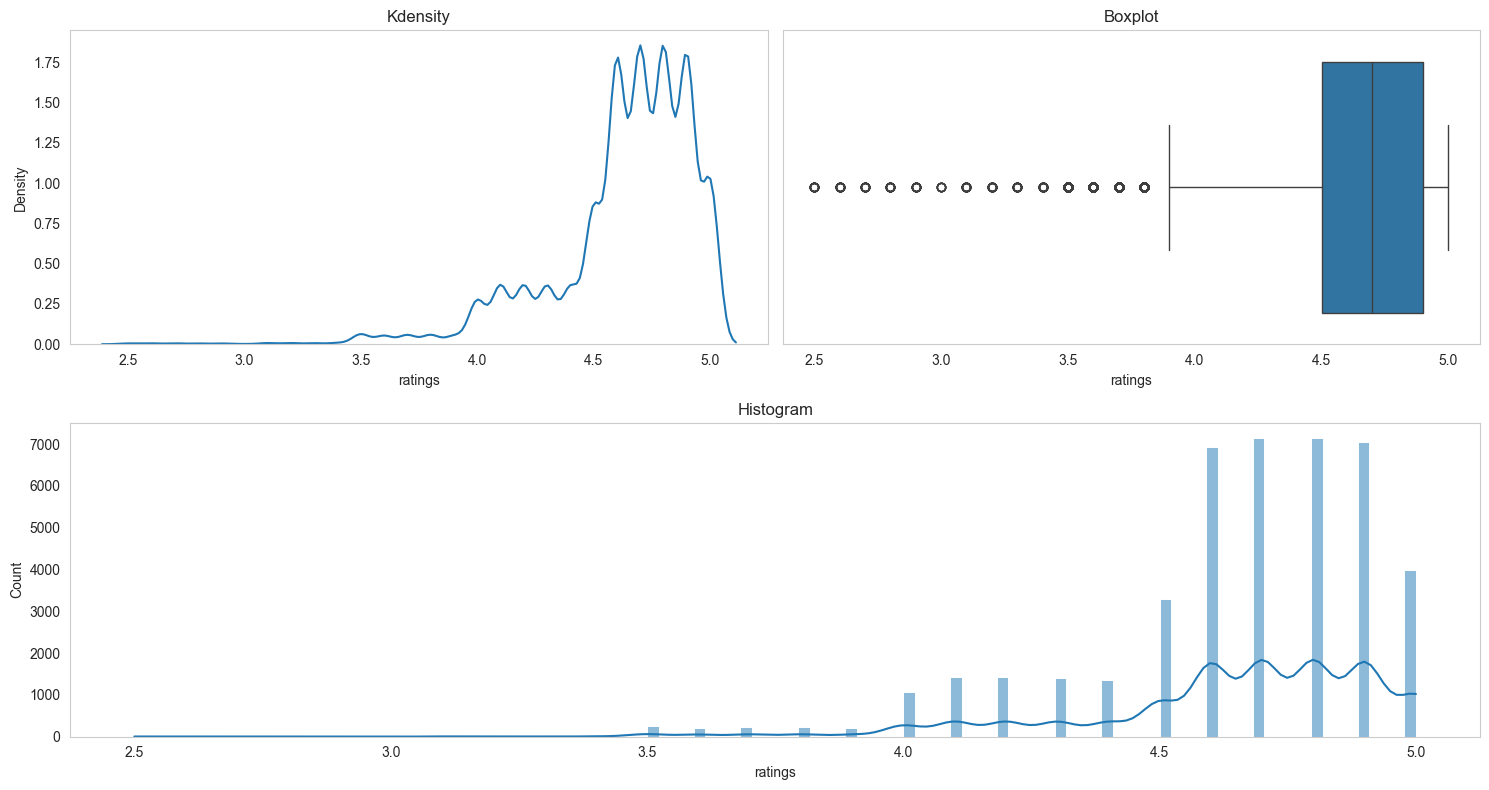

In [9]:
uni_num('ratings')

<Axes: xlabel='ratings', ylabel='time'>

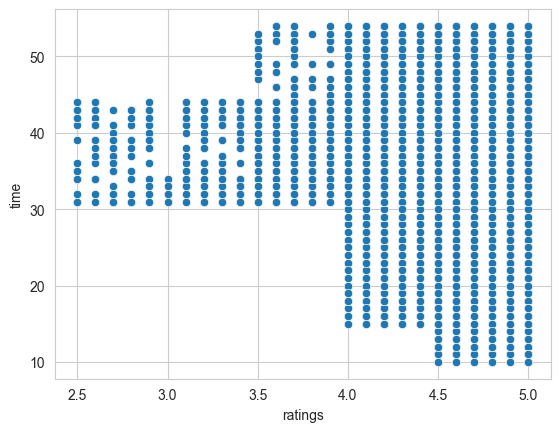

In [10]:
sns.scatterplot(x=cleaned_df['ratings'],y=cleaned_df['time'])

Rider's Rating is left skewed with multimodality, it does not have any visible impact on the delivery time.

There are 4 unique values in traffic column 

There are 1.0% missing values in traffic column 

traffic
low       0.343994
jam       0.314345
medium    0.243310
high      0.098351
Name: proportion, dtype: float64 



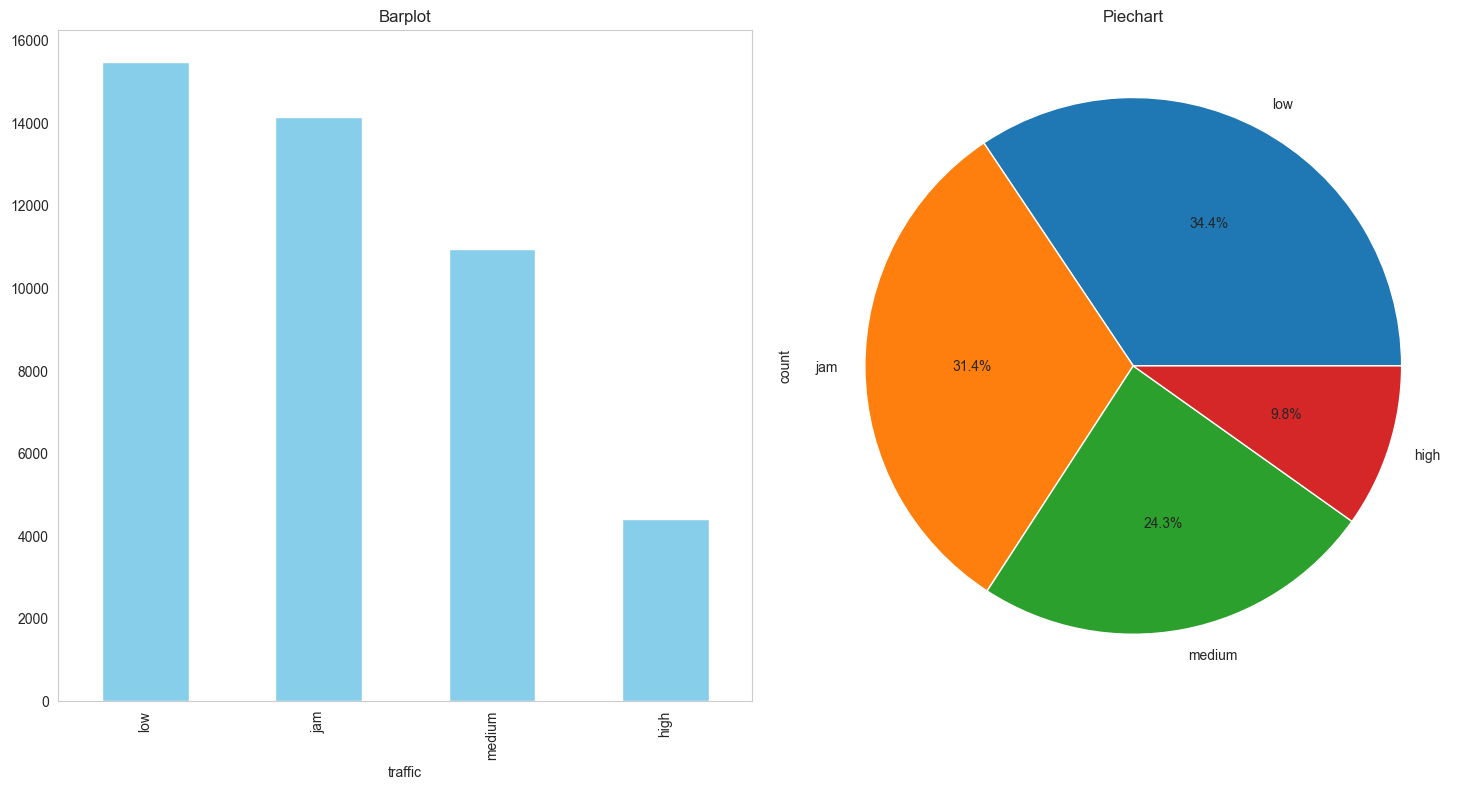

In [11]:
uni_cat('traffic')

p_value : 0.0000 

There is a significant difference between the means of the groups 



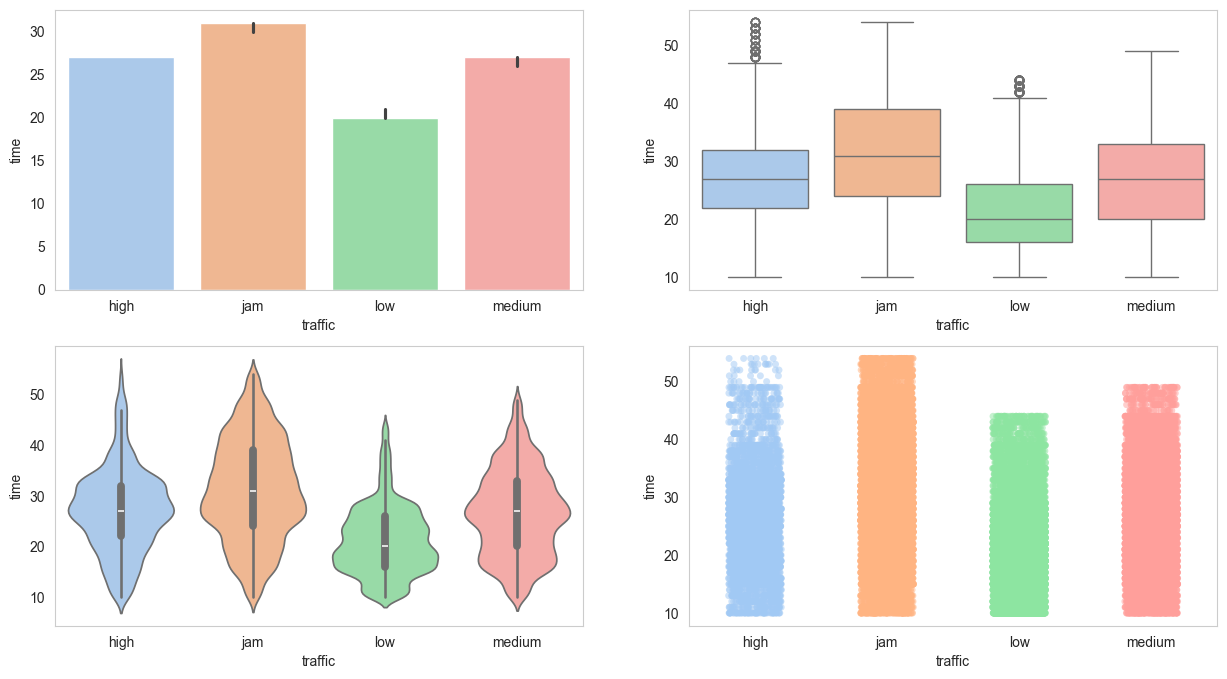

In [12]:
num_cat('time','traffic')

(1) As the mean time for traffic situation is different it is an important feature to predict the delivery time.  
(2) Median Delivery time is highest when there is traffic jam is 30 minutes and lowest when there is no traffic is close to 20 minutes.

There are 6 unique values in weather column 

There are 1.0% missing values in weather column 

weather
fog           0.170176
stormy        0.168664
cloudy        0.167552
sandstorms    0.166641
windy         0.165018
sunny         0.161949
Name: proportion, dtype: float64 



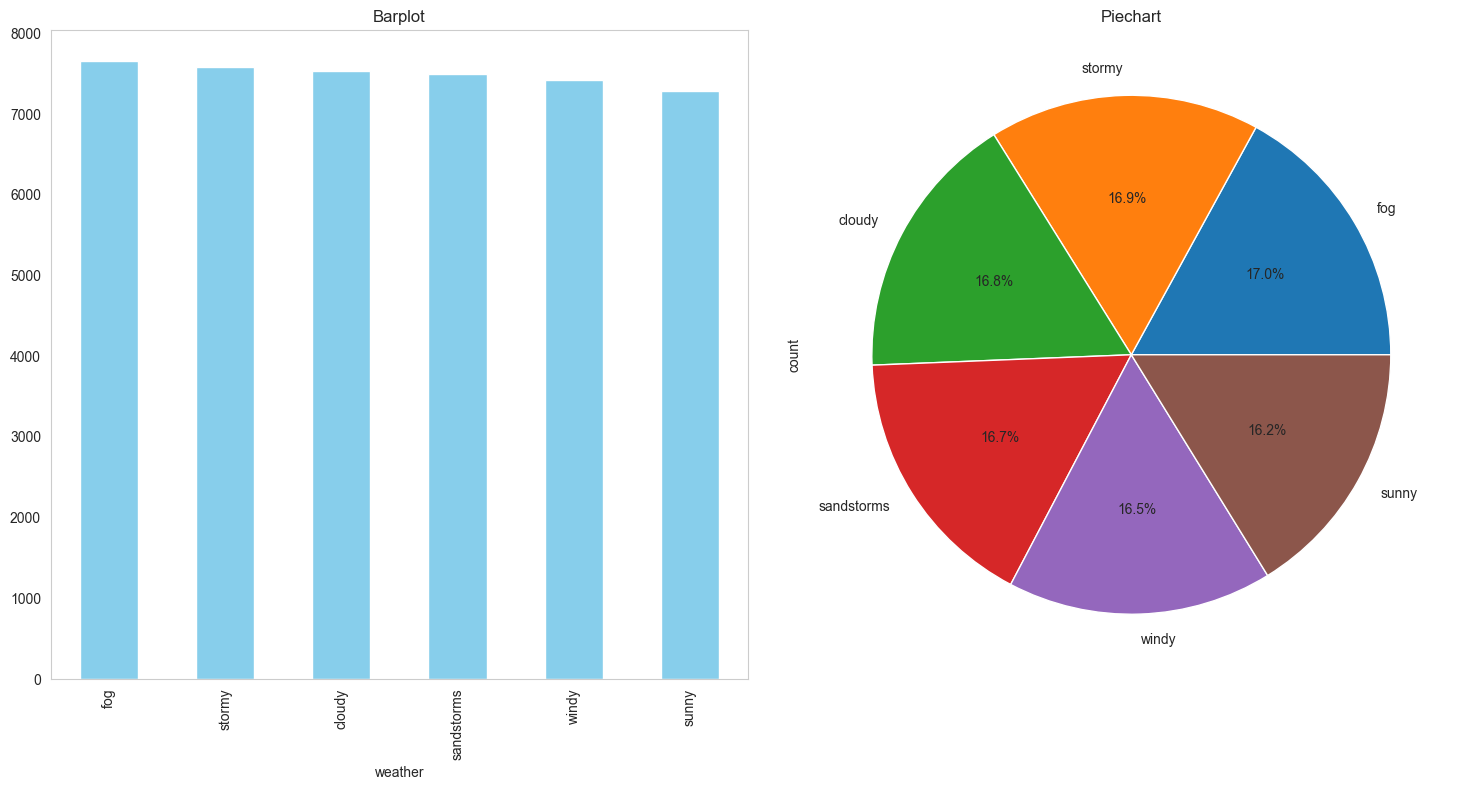

In [13]:
uni_cat('weather')

p_value : 0.0000 

There is a significant difference between the means of the groups 



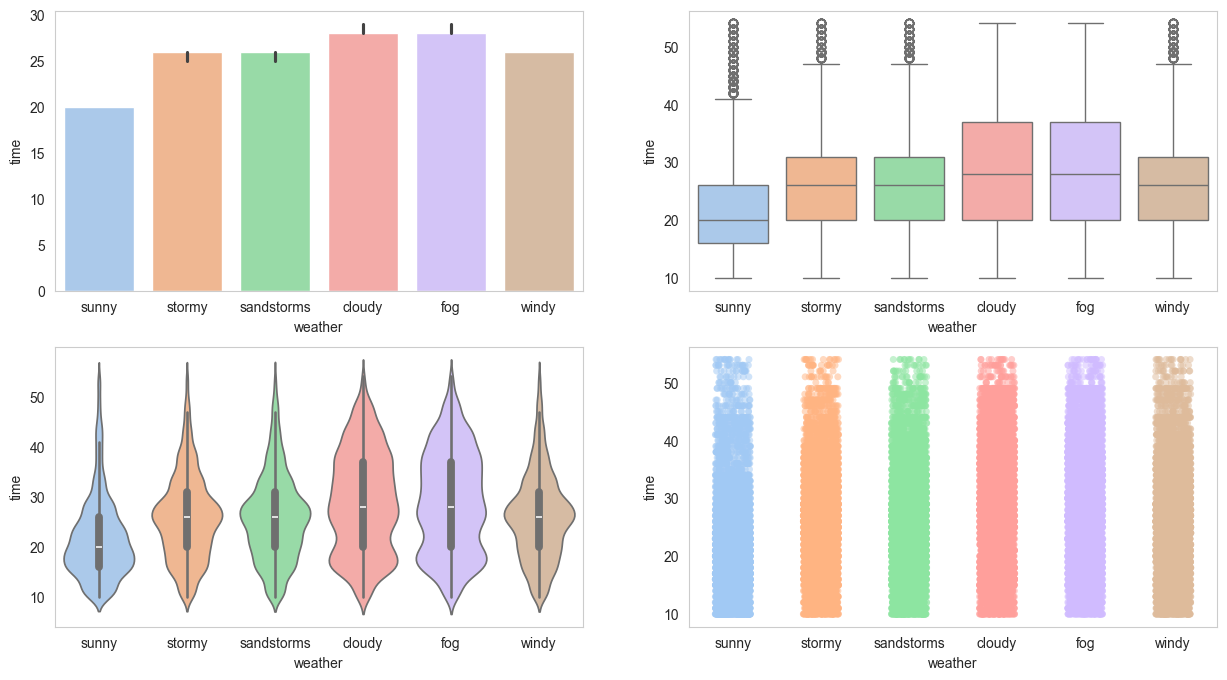

In [14]:
num_cat('time','weather')

(1) Although The Delivery time evenly distributed among all the weather conditions, the anova test says it has a significant impact on the delivery time.  
(2) There are high outliers in the delivery time for sunny, stormy, sandstorm weather conditions.  
(3) Median delivery time for sunny weather is 20 minutes which is the lowest.  
(4) Stormy, Sandstorm and windy weather exhibiting simillar type of distribution. We can group them together as adverse weather conditions.

There are 4 unique values in vehicle_condition column 

There are 0.0% missing values in vehicle_condition column 

vehicle_condition
1    0.330403
2    0.330315
3    0.329854
0    0.009428
Name: proportion, dtype: float64 



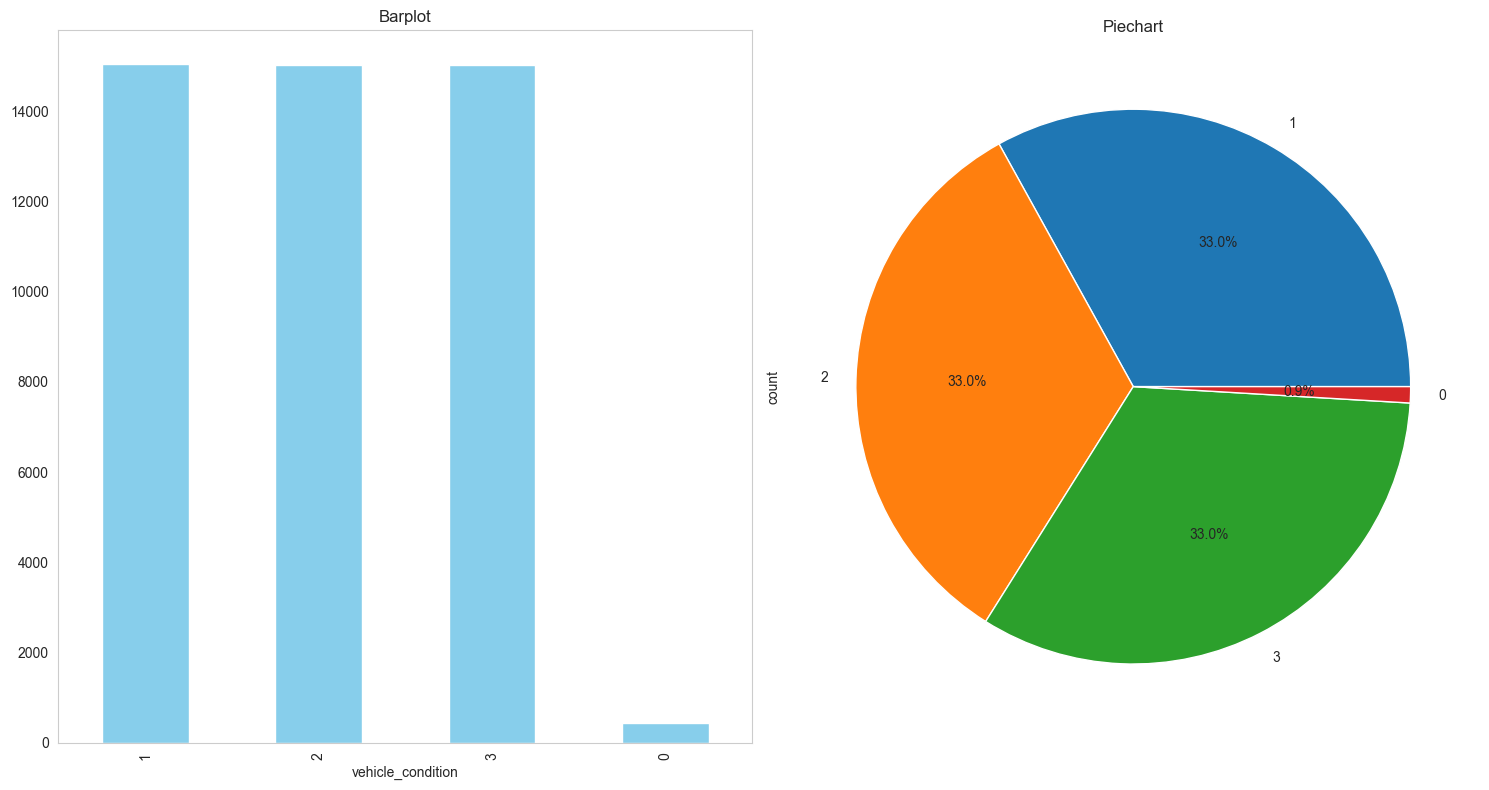

In [15]:
uni_cat('vehicle_condition')

p_value : 0.0000 

There is a significant difference between the means of the groups 



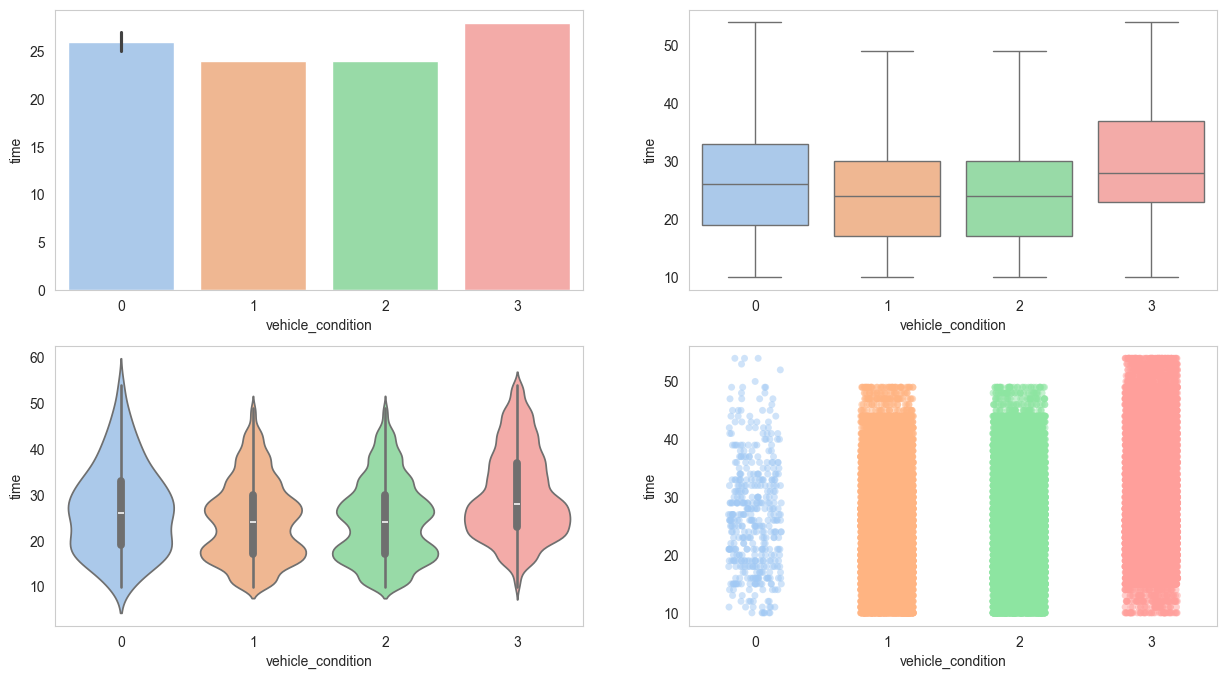

In [16]:
num_cat('time','vehicle_condition')

(1) Median time for each vehicle condition is almost simillar.  
(2) There are very low data for vehicle condition 0.  
(3) Other vehicle conditions exhibiting simillar type of distribution. 

There are 4 unique values in order_type column 

There are 0.0% missing values in order_type column 

order_type
snack     0.253000
meal      0.251308
drinks    0.248209
buffet    0.247484
Name: proportion, dtype: float64 



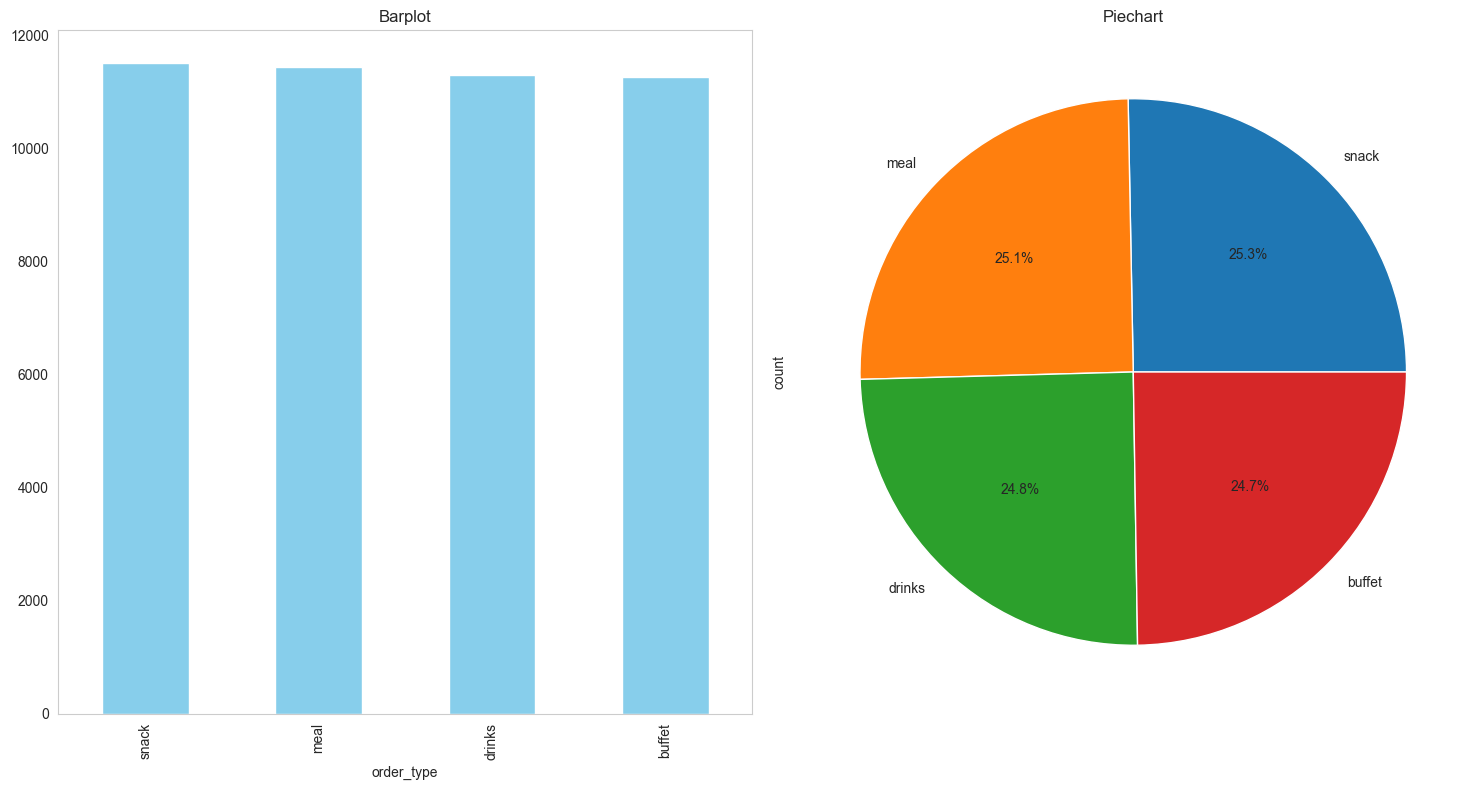

In [17]:
uni_cat('order_type')

p_value : 0.2250 

There is no significant difference between the means of the groups 



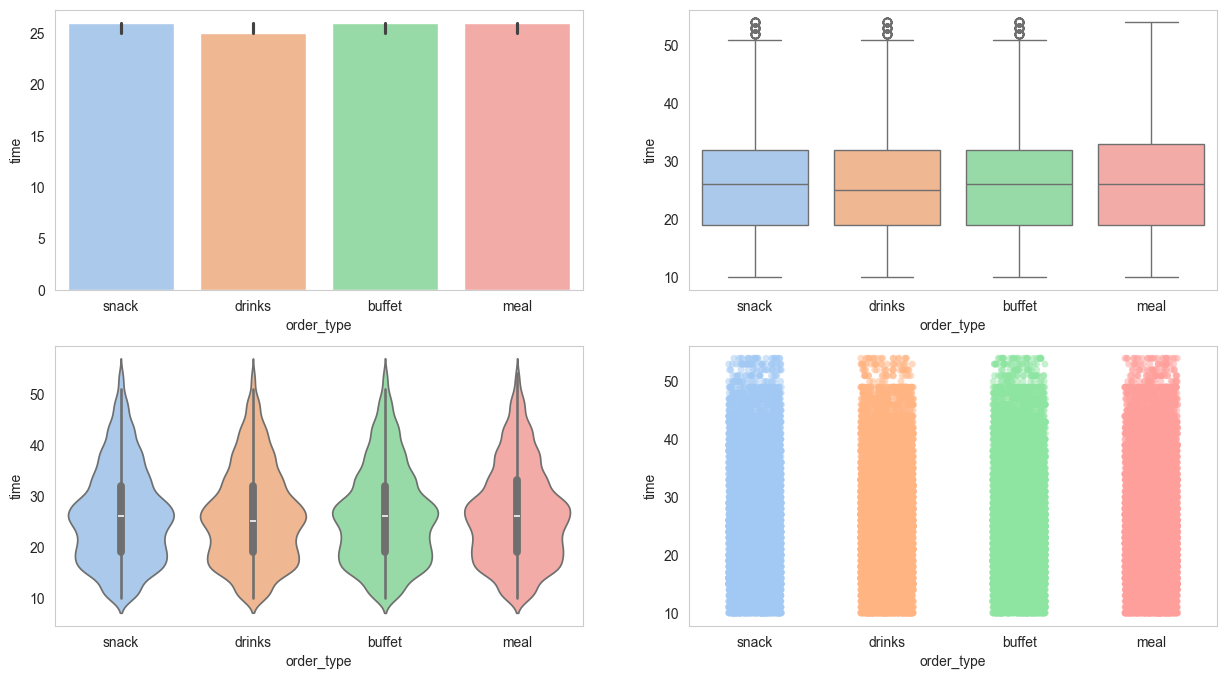

In [18]:
num_cat('time','order_type')

(1) Each order type has simillar distribution and central tendancy.  
(2) There is no impact of order type on the delivery time.

There are 4 unique values in vehicle_type column 

There are 0.0% missing values in vehicle_type column 

vehicle_type
motorcycle          0.580788
scooter             0.335018
electric_scooter    0.083029
bicycle             0.001165
Name: proportion, dtype: float64 



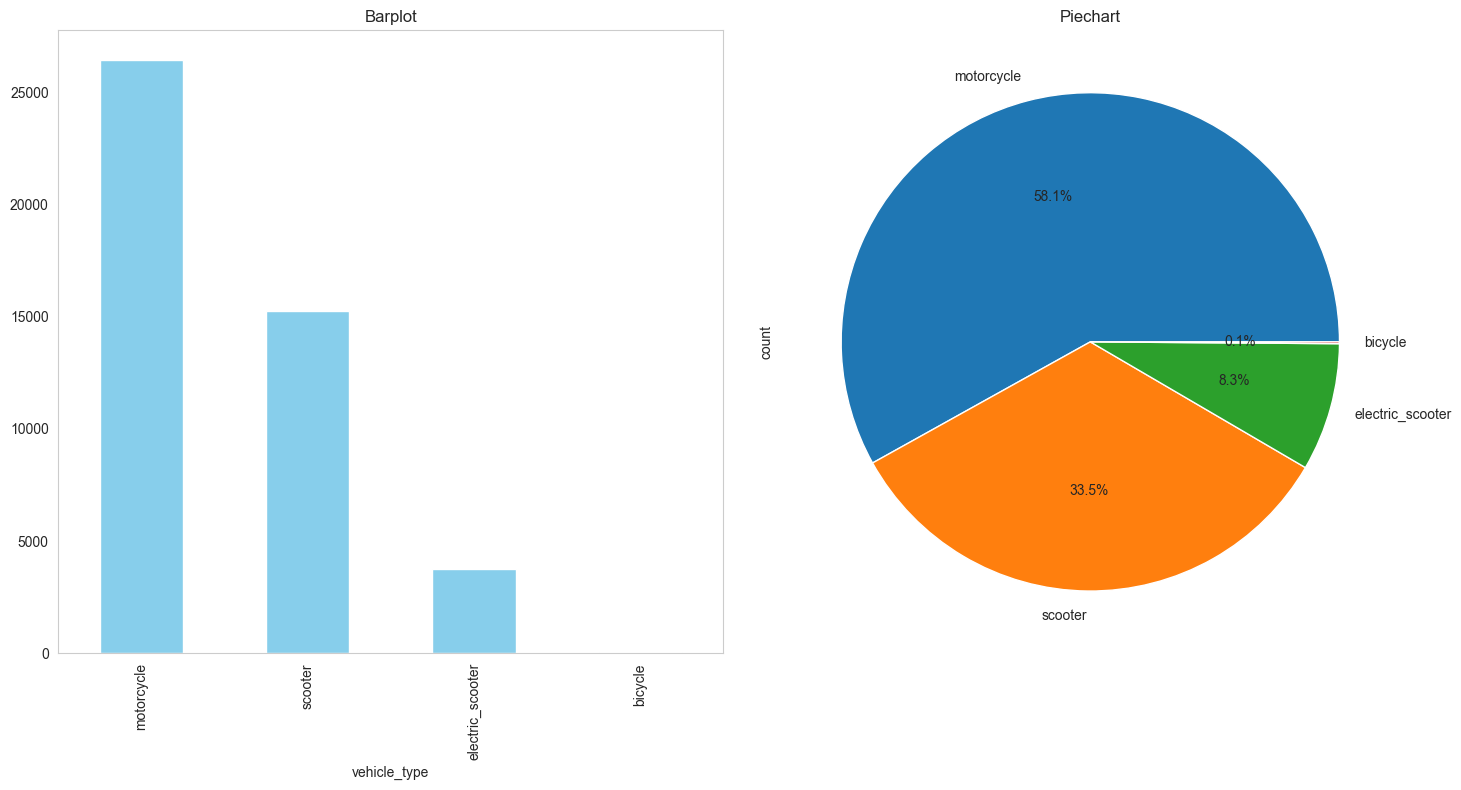

In [19]:
uni_cat('vehicle_type')

p_value : 0.0000 

There is a significant difference between the means of the groups 



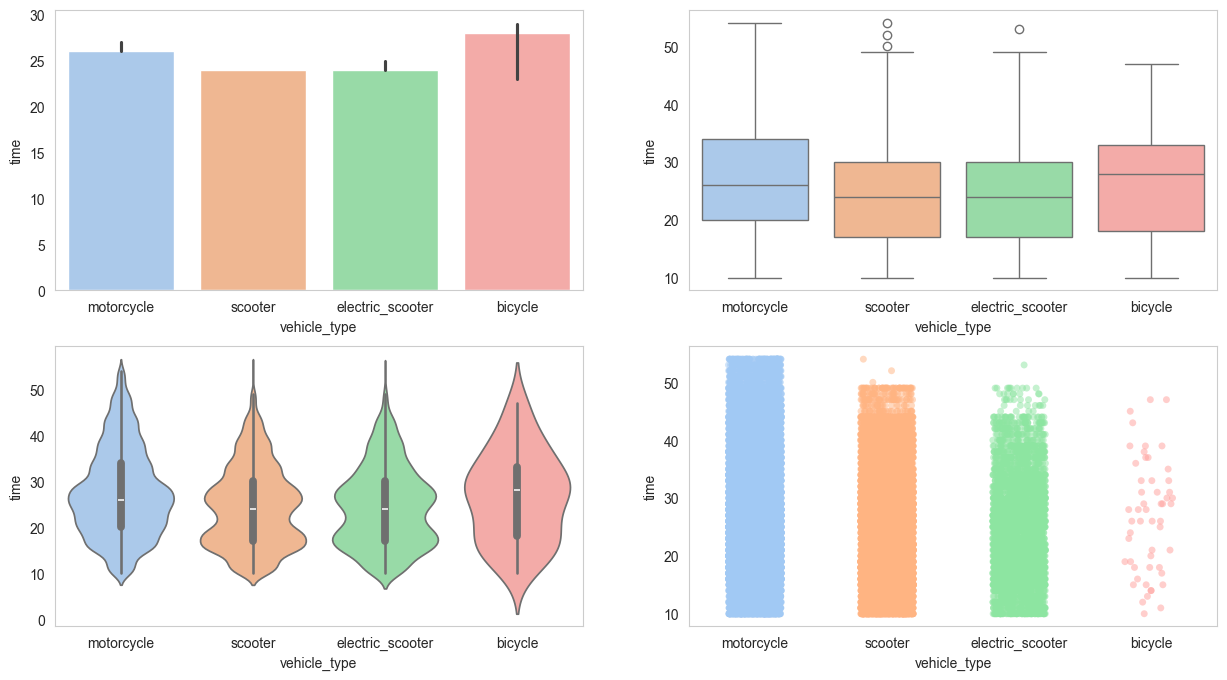

In [20]:
num_cat('time','vehicle_type')

(1) Highest Number of vehicle type is Motorcycle with 58% and median delivery time is 25 minutes.  
(2) Very few data for bicycle even though it shows highest median time.  
(3) Significant Impact on the delivery time.

There are 4 unique values in multiple_deliveries column 

There are 2.0% missing values in multiple_deliveries column 

multiple_deliveries
1.0    0.631535
0.0    0.315824
2.0    0.044530
3.0    0.008111
Name: proportion, dtype: float64 



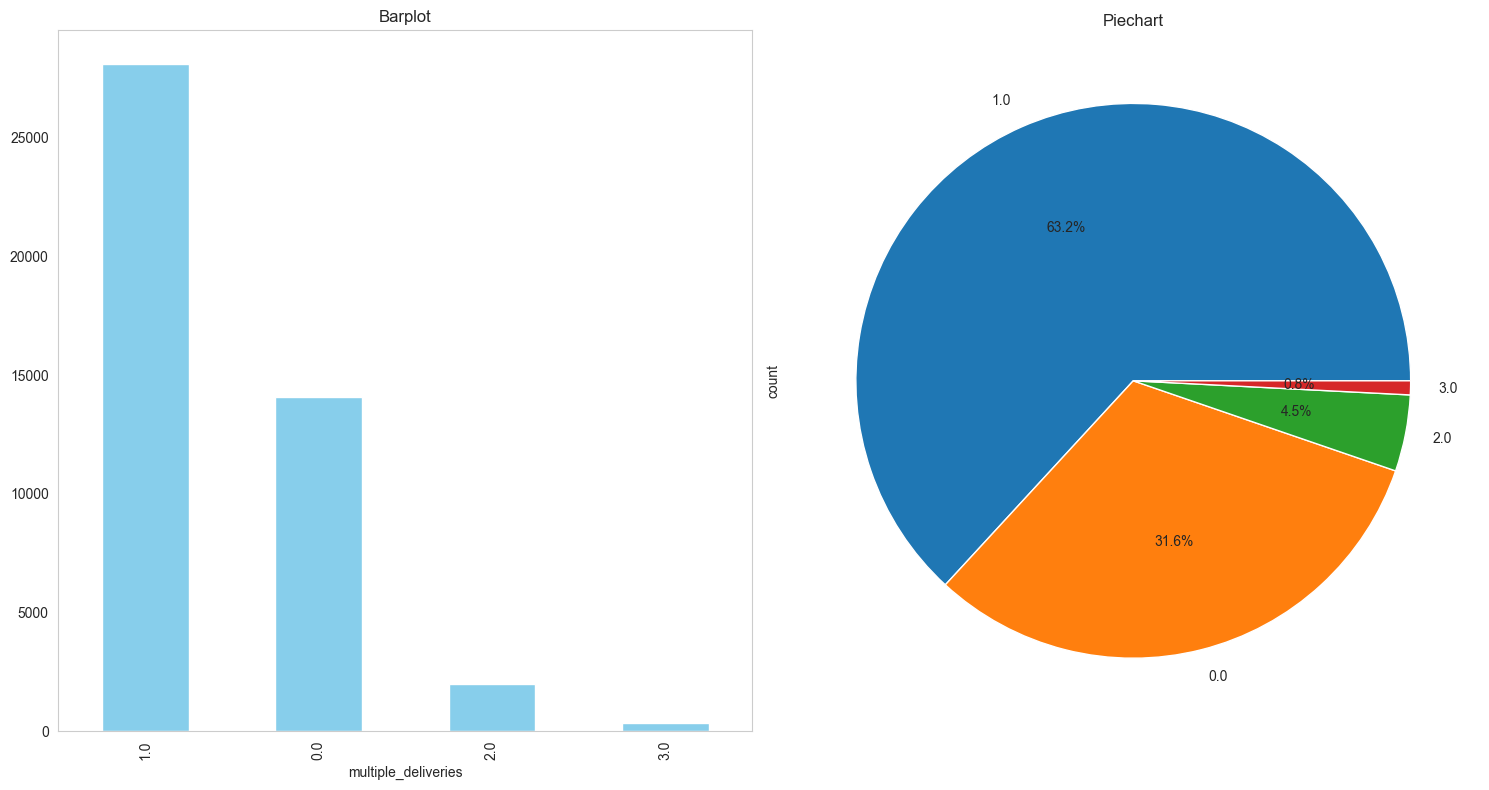

In [21]:
uni_cat('multiple_deliveries')

p_value : 0.0000 

There is a significant difference between the means of the groups 



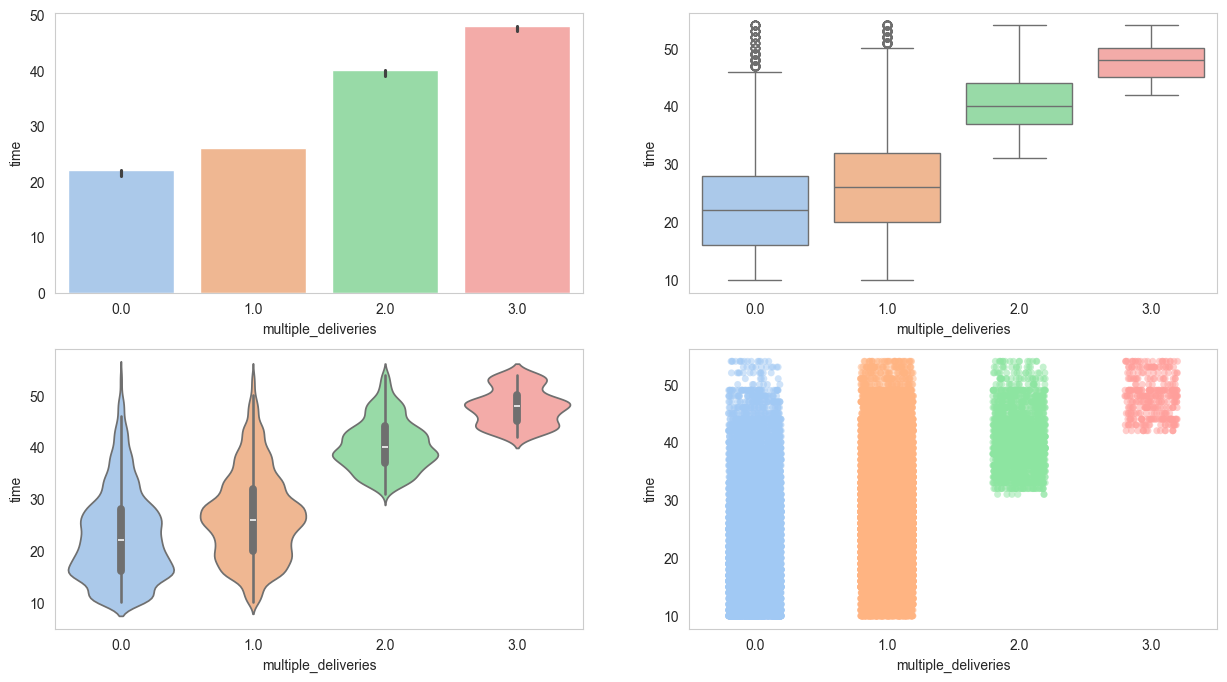

In [22]:
num_cat('time','multiple_deliveries')

(1) Delivery time increases as multiple deliveries increases.  
(2) Although there are not many data available but the time range for 2 and 3 multiple deliveries is 35-50 mintutes.  
(3) we can merge multiple deliveries 2 and 3 together to control their sample size and variance.  
(4) Highest number of deliveries has 1 multiple delivery.

There are 2 unique values in festival column 

There are 1.0% missing values in festival column 

festival
no     0.980254
yes    0.019746
Name: proportion, dtype: float64 



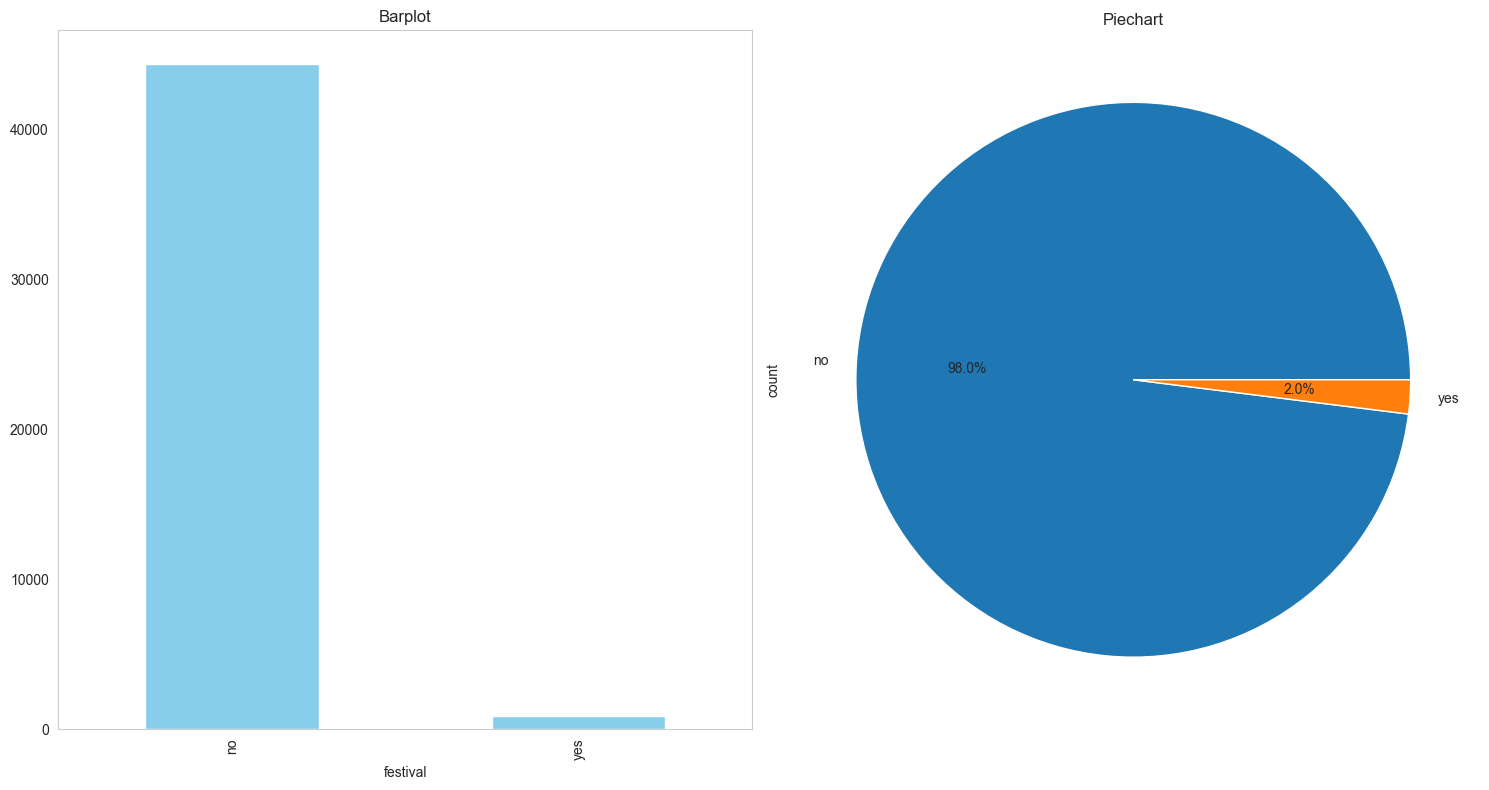

In [23]:
uni_cat('festival')

p_value : 0.0000 

There is a significant difference between the means of the groups 



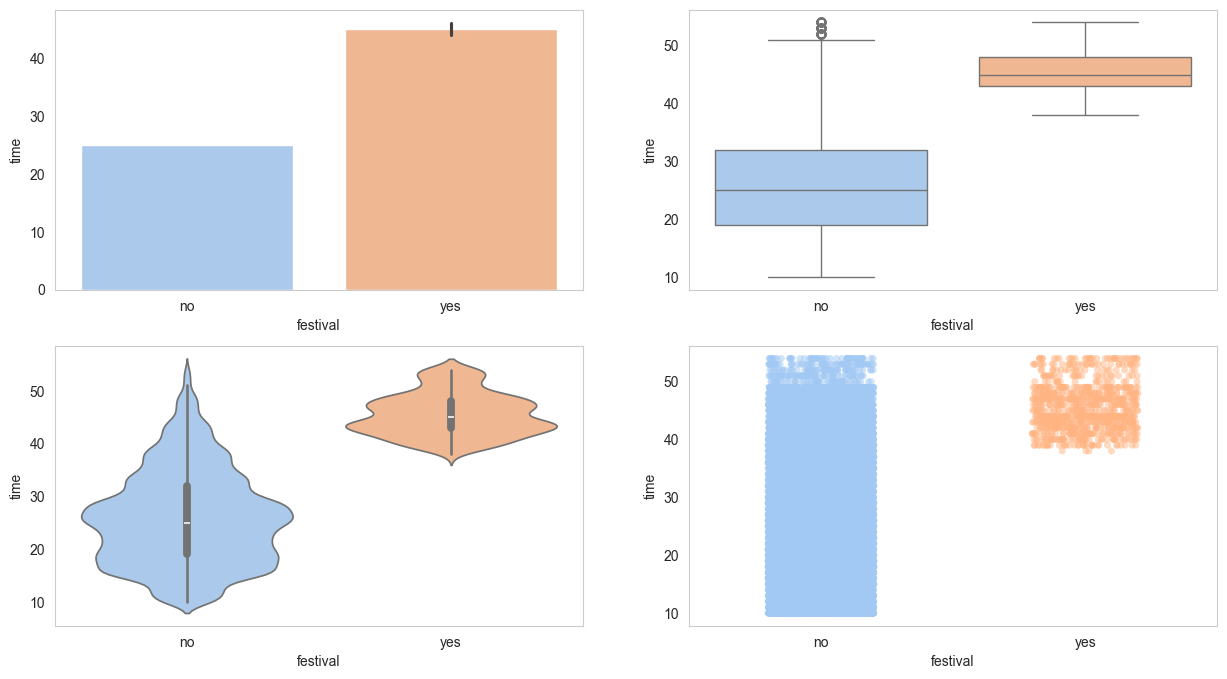

In [24]:
num_cat('time','festival')

(1) During the festivals the median delivery time increases from 25 to 45 minutes.  
(2) Data available for festivals is very low at 2%.

There are 3 unique values in city_type column 

There are 3.0% missing values in city_type column 

city_type
metropolitian    0.768080
urban            0.228219
semi-urban       0.003702
Name: proportion, dtype: float64 



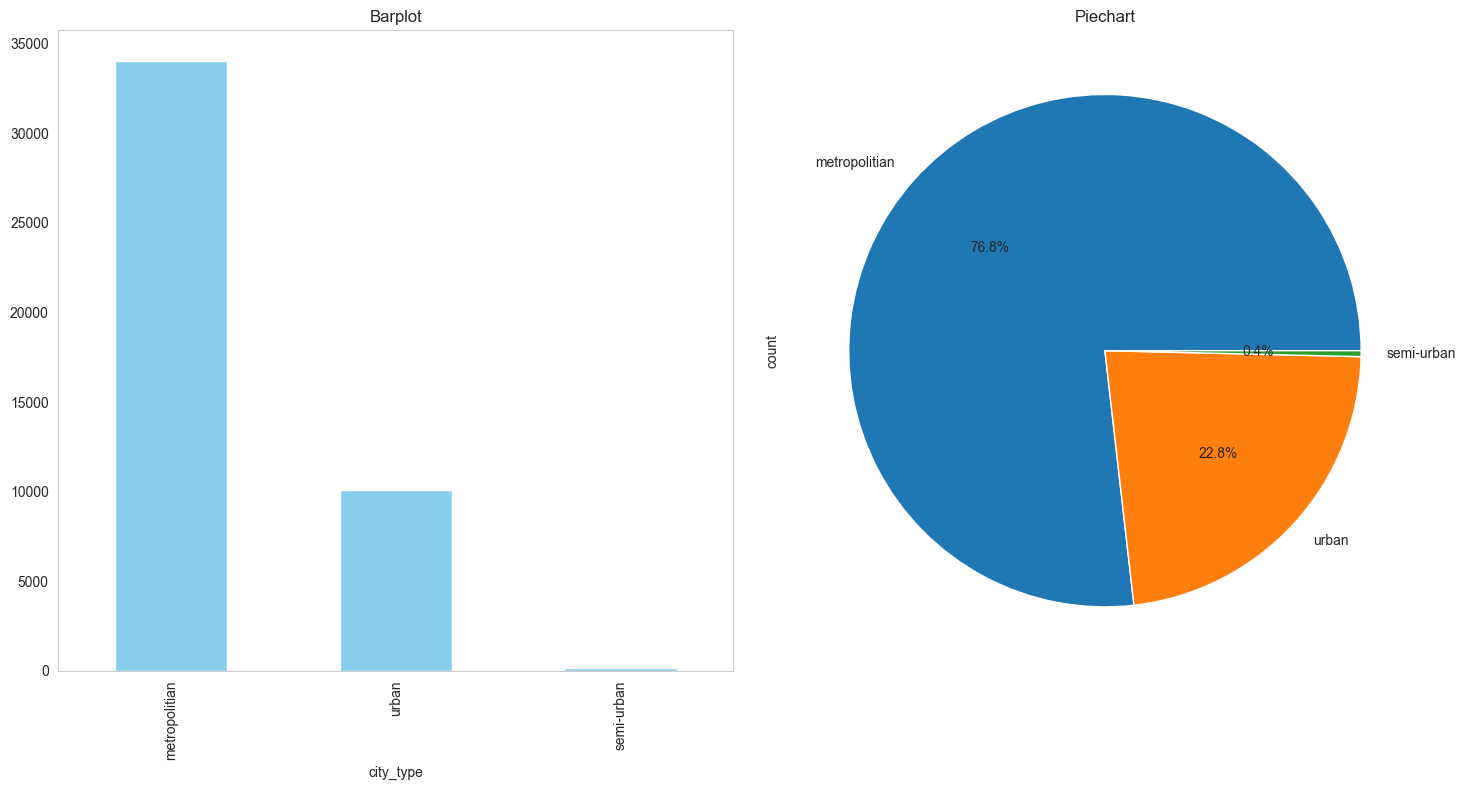

In [25]:
uni_cat('city_type')

p_value : 0.0000 

There is a significant difference between the means of the groups 



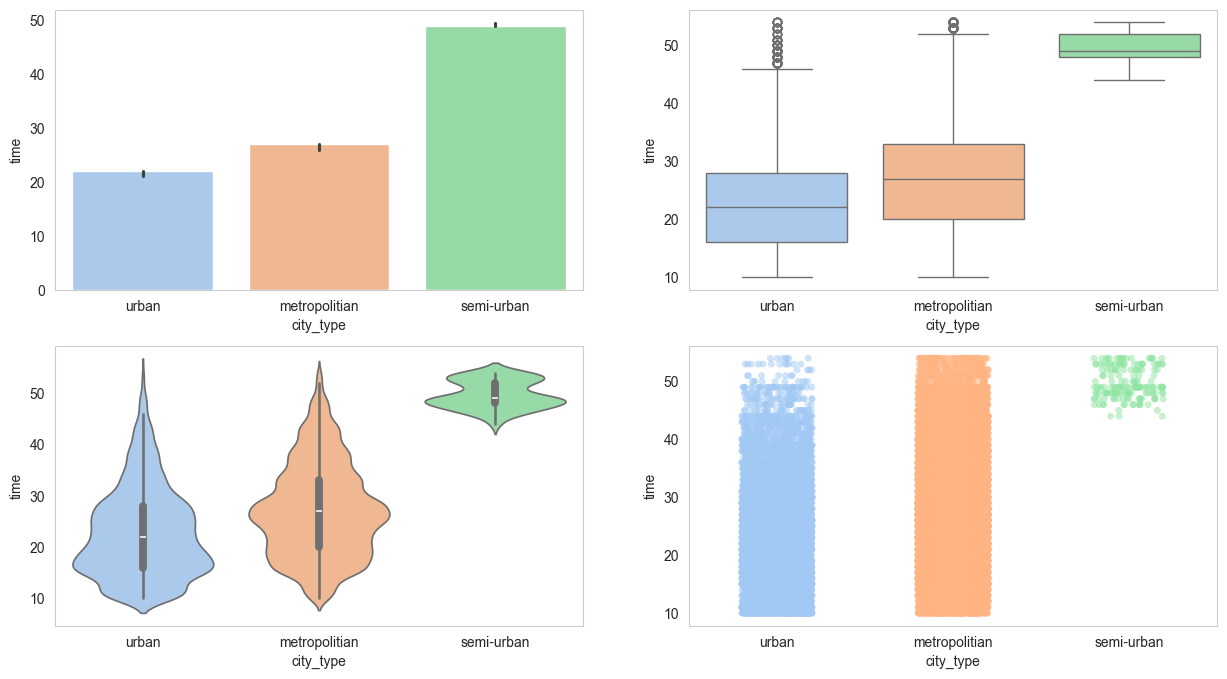

In [26]:
num_cat('time','city_type')

(1) 76% of the delivery is in metropolitan cities with median delivery time of 26-27 minutes.  
(2) Very low data for semi-urban at 0.4%.

count    45502.000000
mean        26.297591
std          9.386419
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time, dtype: float64 

Skewness : 0.485582469348261 

p_value : 0.0000 

Data is not normally distributed 

Data has outliers 

Kurtosis : -0.3116377537837778


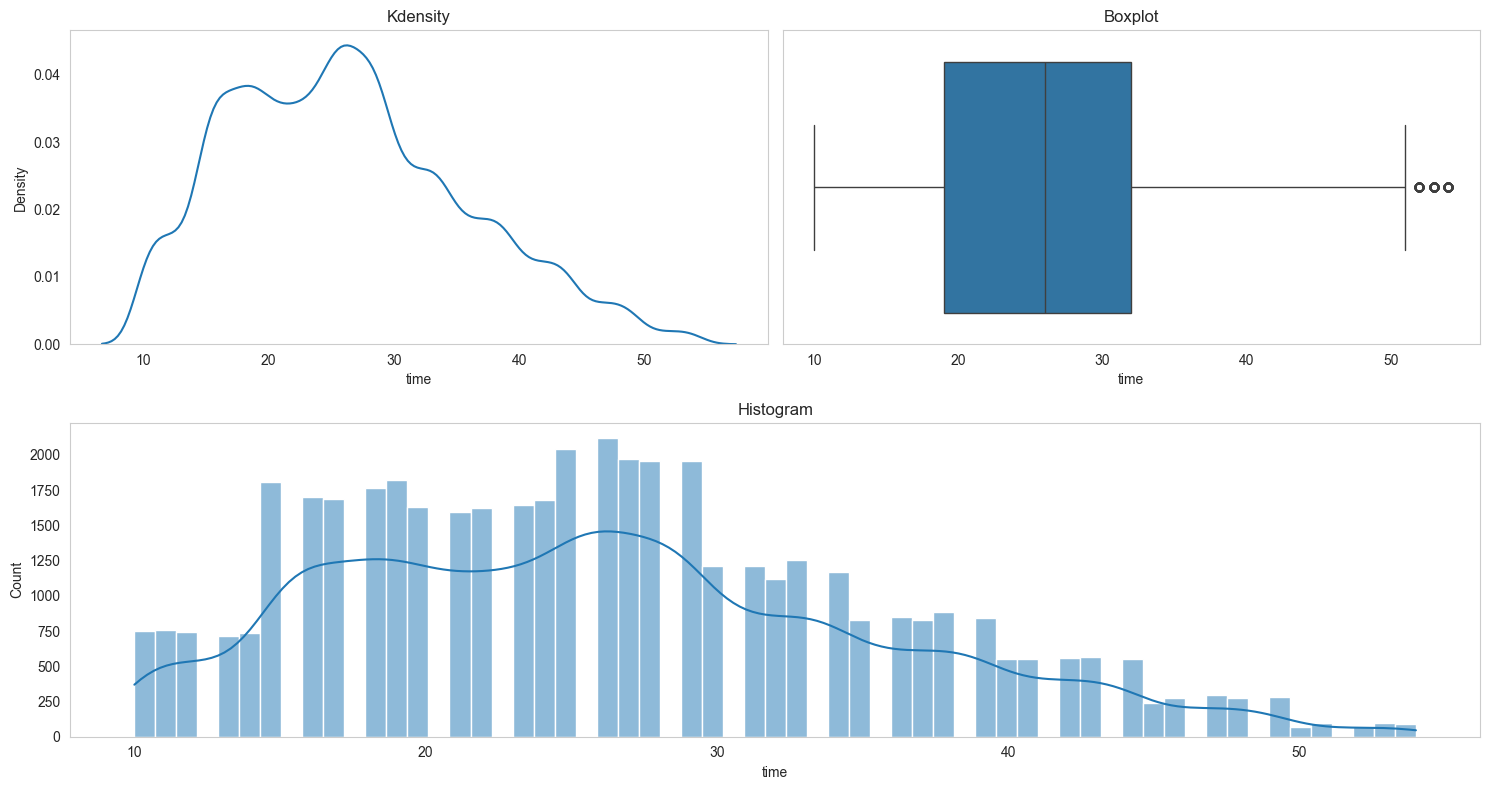

In [27]:
uni_num('time')

(1) Mean and Median delivery time is almost simillar at 26 minutes.  
(2) We can see multi modality with 2 peaks at 17-18 and 26-27 minutes.  
(3) skewness is satisfactory at 0.48 and the kurtosis values are also low.    
(4) that's why we can ignore the outliers.

count    41872.000000
mean         9.719272
std          5.602944
min          1.470000
25%          4.660000
50%          9.190000
75%         13.680000
max         20.970000
Name: distance_km, dtype: float64 

Skewness : 0.32497096928519625 

p_value : nan 

Data is normally distributed 

Data does not have outliers 

Kurtosis : -0.9054558193298532


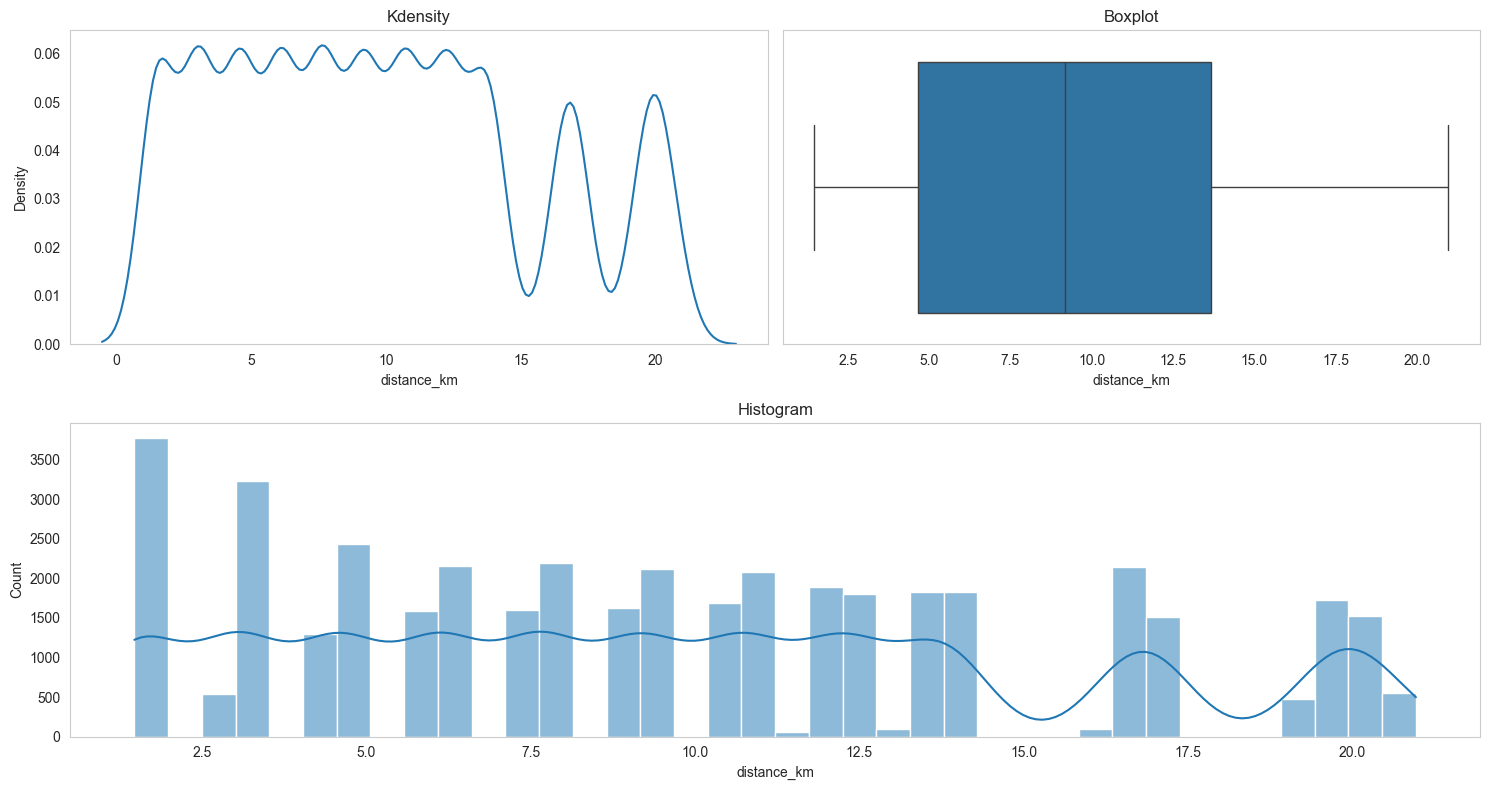

In [28]:
uni_num('distance_km')

<Axes: xlabel='distance_km', ylabel='time'>

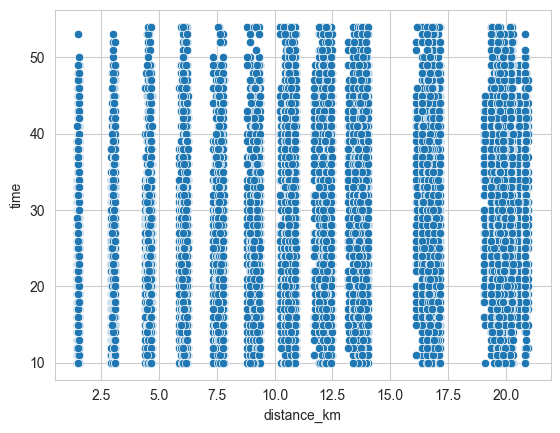

In [29]:
sns.scatterplot(x=cleaned_df['distance_km'],y=cleaned_df['time'])

(1) Distance in KM has multimodal distribution.  
(2) Distance is almost distributed as categorically.

There are 21 unique values in day column 

There are 0.0% missing values in day column 

day
3     0.280845
4     0.139620
15    0.046899
13    0.046591
17    0.045493
16    0.040680
2     0.040284
14    0.040020
18    0.039932
26    0.025625
24    0.025471
19    0.025208
21    0.025142
30    0.025032
28    0.025032
20    0.021757
29    0.021428
25    0.021406
31    0.021230
23    0.021164
27    0.021142
Name: proportion, dtype: float64 



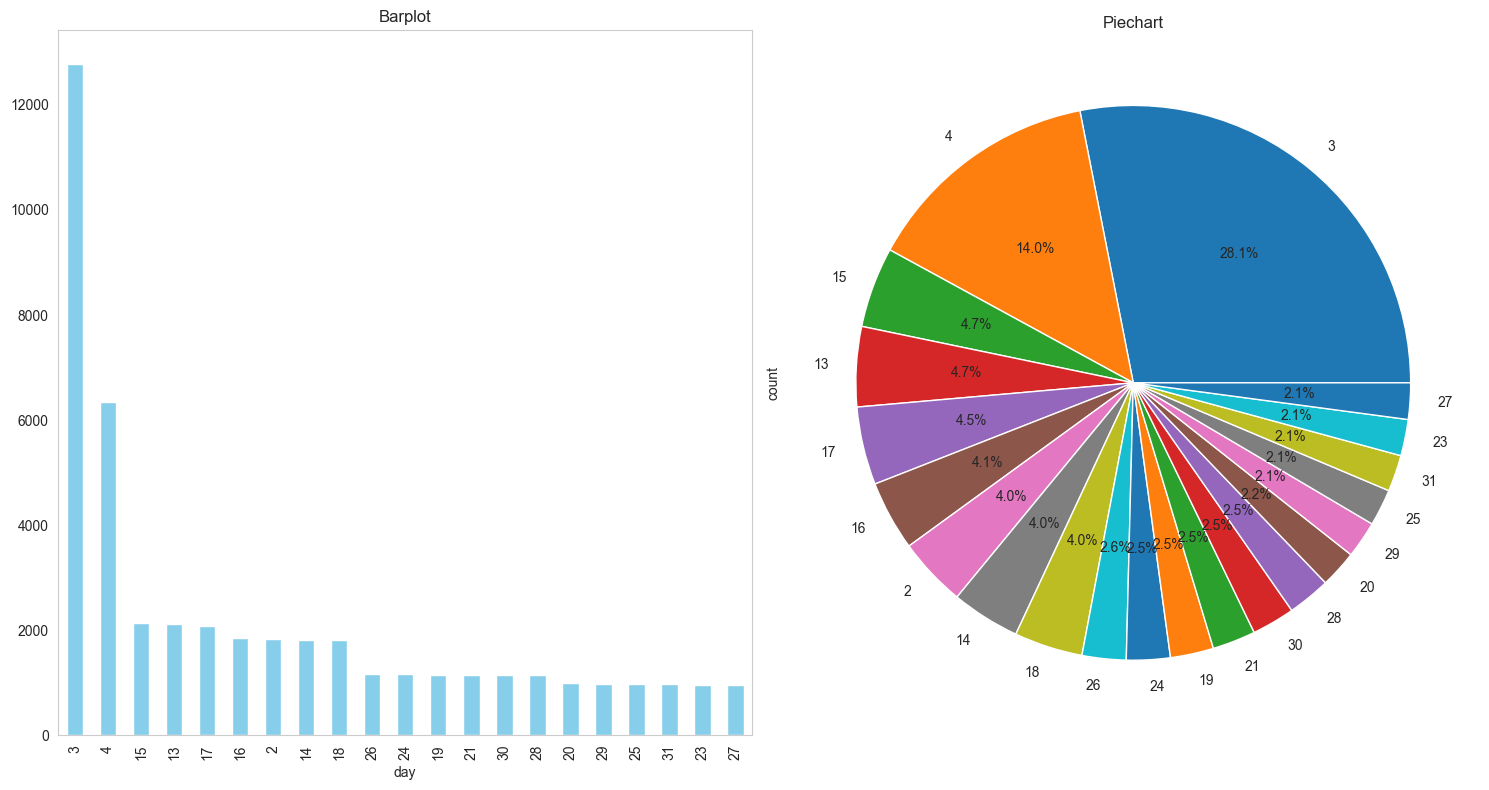

In [30]:
uni_cat('day')

p_value : 0.0000 

There is a significant difference between the means of the groups 



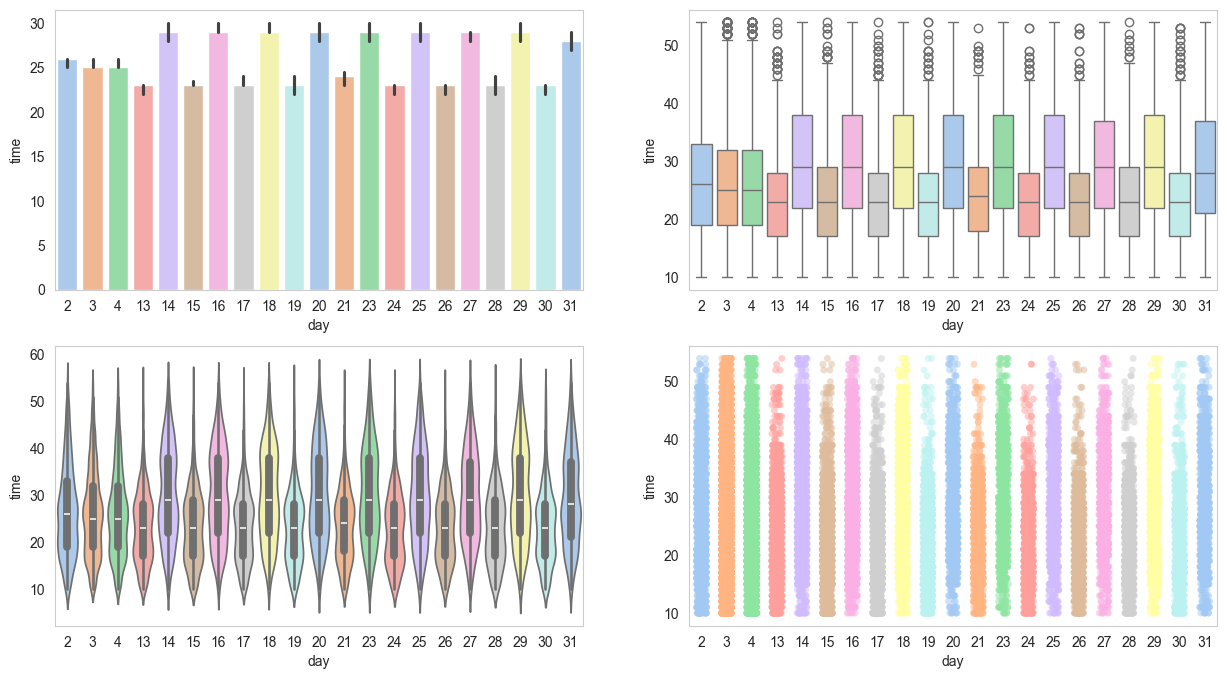

In [31]:
num_cat('time','day')

(1) 3rd and 4th days of the month has highest number of deliveries at 42% of total order.

There are 12 unique values in month column 

There are 0.0% missing values in month column 

month
3     0.471694
2     0.162542
5     0.050723
1     0.049844
11    0.046481
6     0.042657
4     0.042218
12    0.040064
9     0.025405
7     0.025340
10    0.021889
8     0.021142
Name: proportion, dtype: float64 



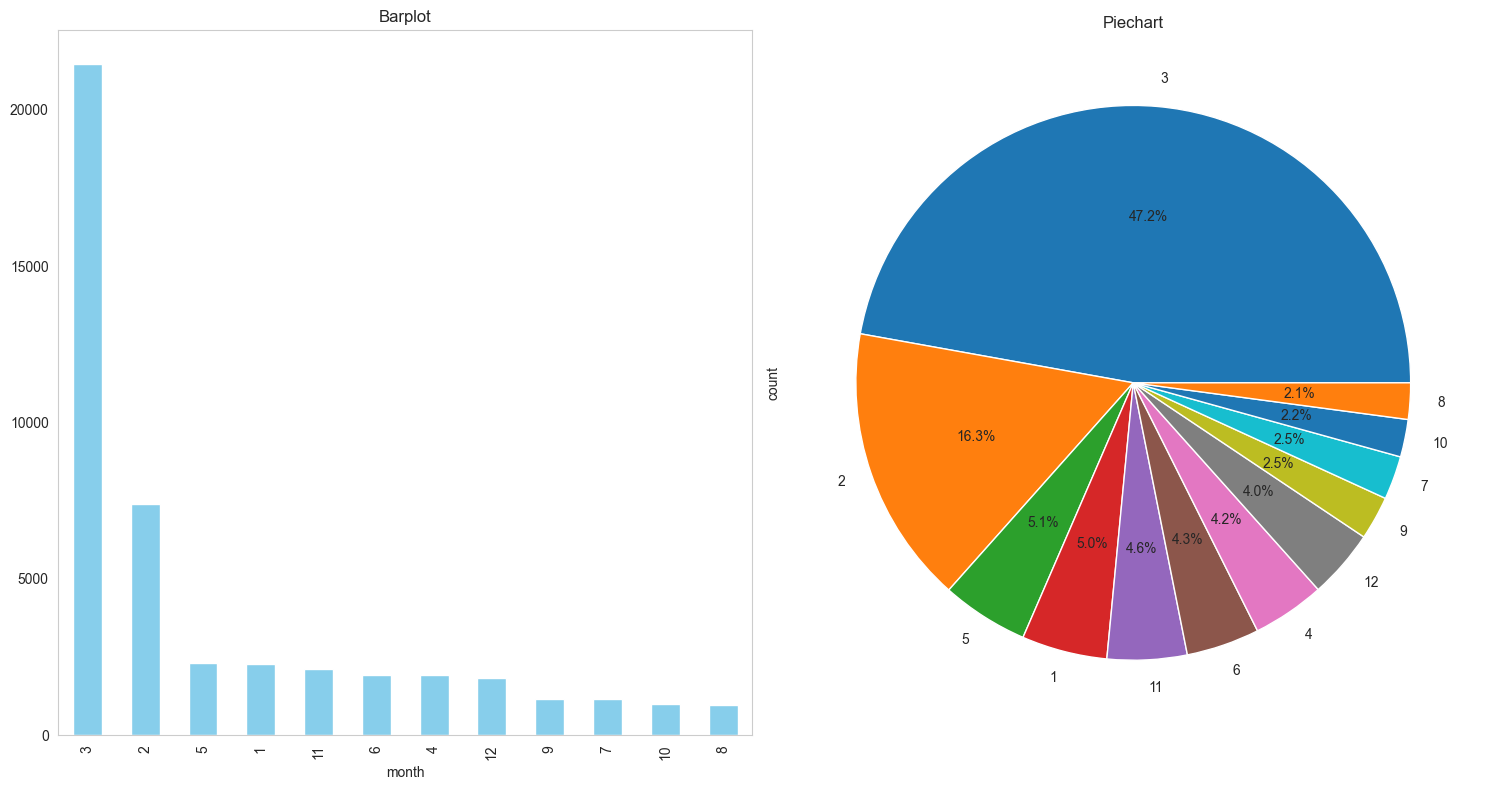

In [32]:
uni_cat('month')

p_value : 0.0000 

There is a significant difference between the means of the groups 



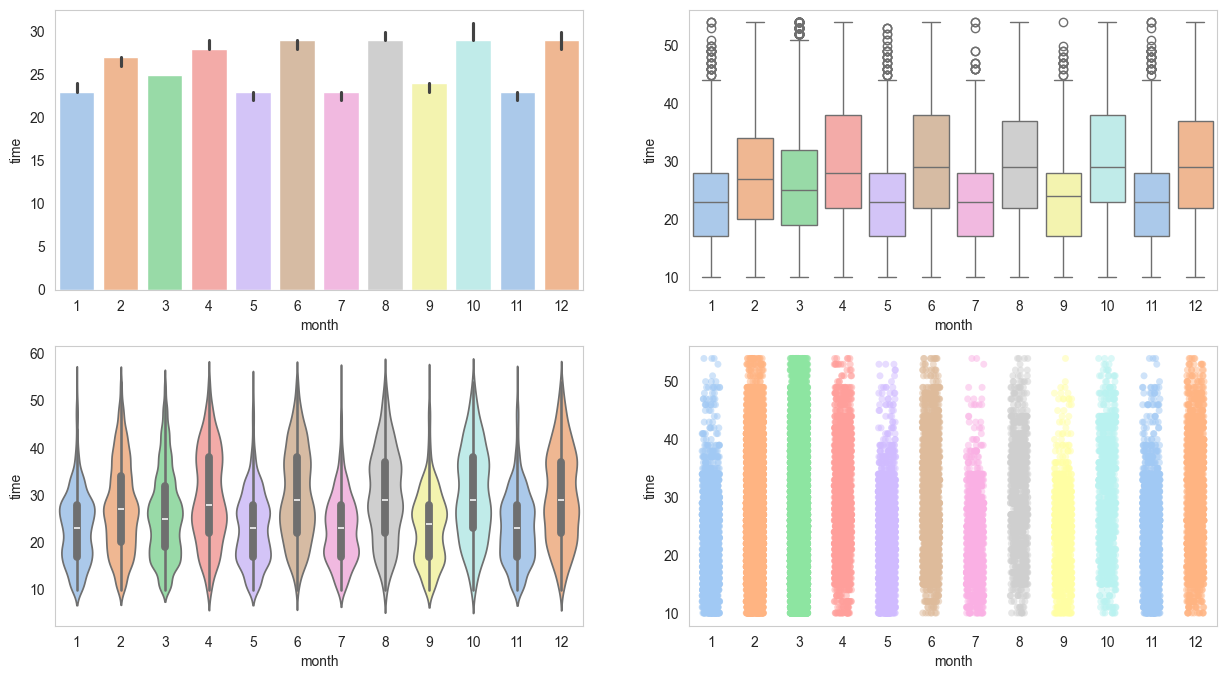

In [33]:
num_cat('time','month')

(1) Februrary and March has highest number of deliveries at 62% of total order.

There are 7 unique values in day_of_week column 

There are 0.0% missing values in day_of_week column 

day_of_week
Thursday     0.164762
Monday       0.157685
Wednesday    0.154762
Friday       0.149488
Sunday       0.136390
Tuesday      0.118522
Saturday     0.118390
Name: proportion, dtype: float64 



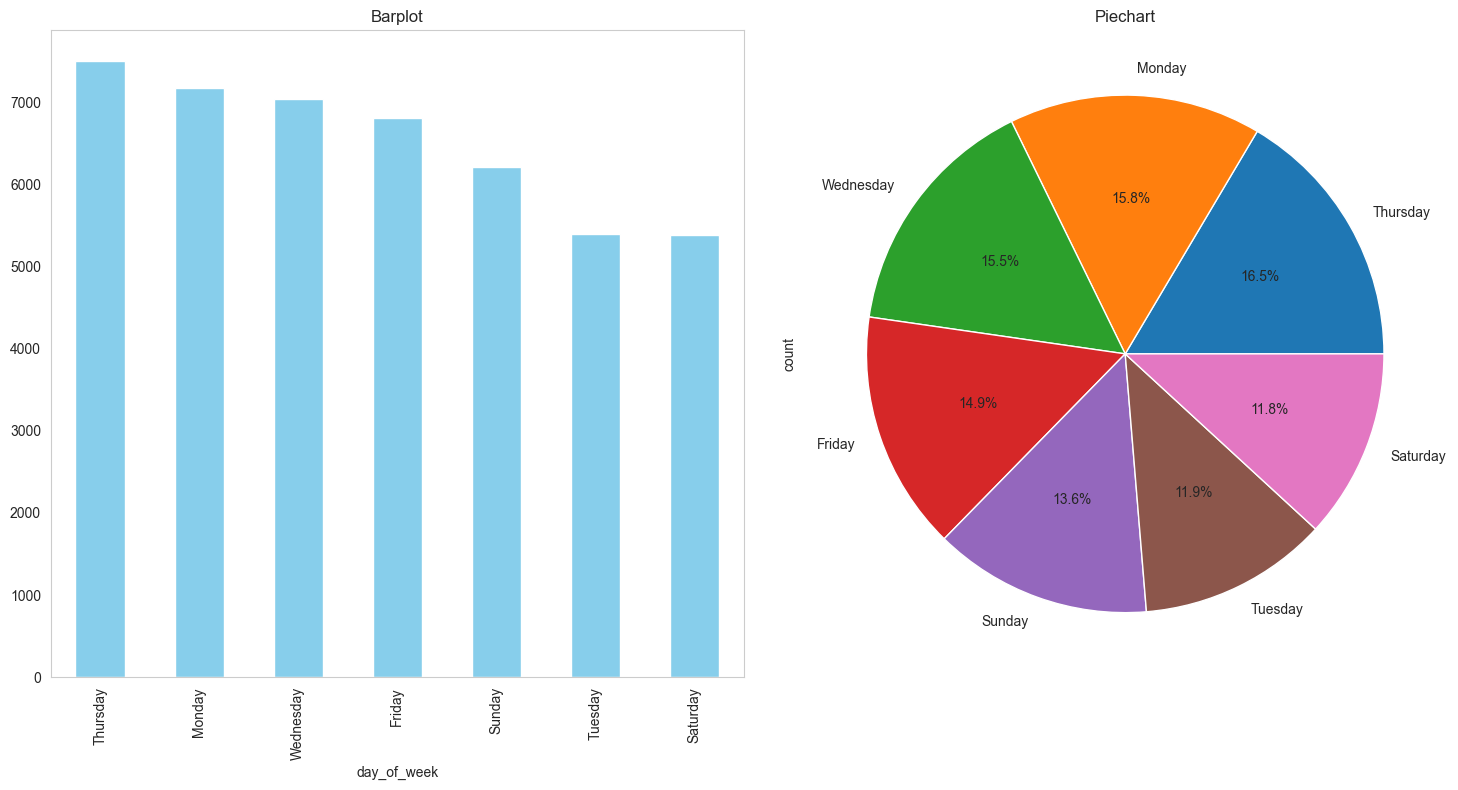

In [34]:
uni_cat('day_of_week')

p_value : 0.0000 

There is a significant difference between the means of the groups 



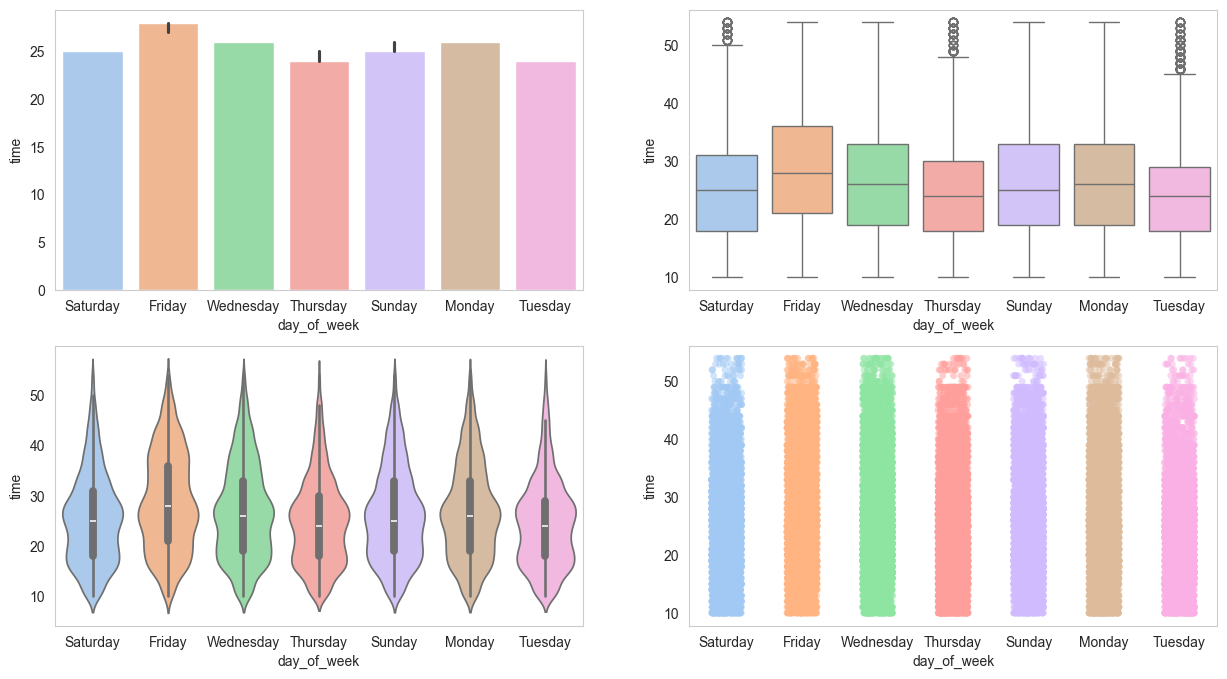

In [35]:
num_cat('time','day_of_week')

(1) Thursday has the highest number of orders and Saturday has the lowest.  
(2) Median delivery time and distribution is almost simillar for each days of week.

There are 3 unique values in pickup_time column 

There are 4.0% missing values in pickup_time column 

pickup_time
5.0     0.335210
15.0    0.333090
10.0    0.331699
Name: proportion, dtype: float64 



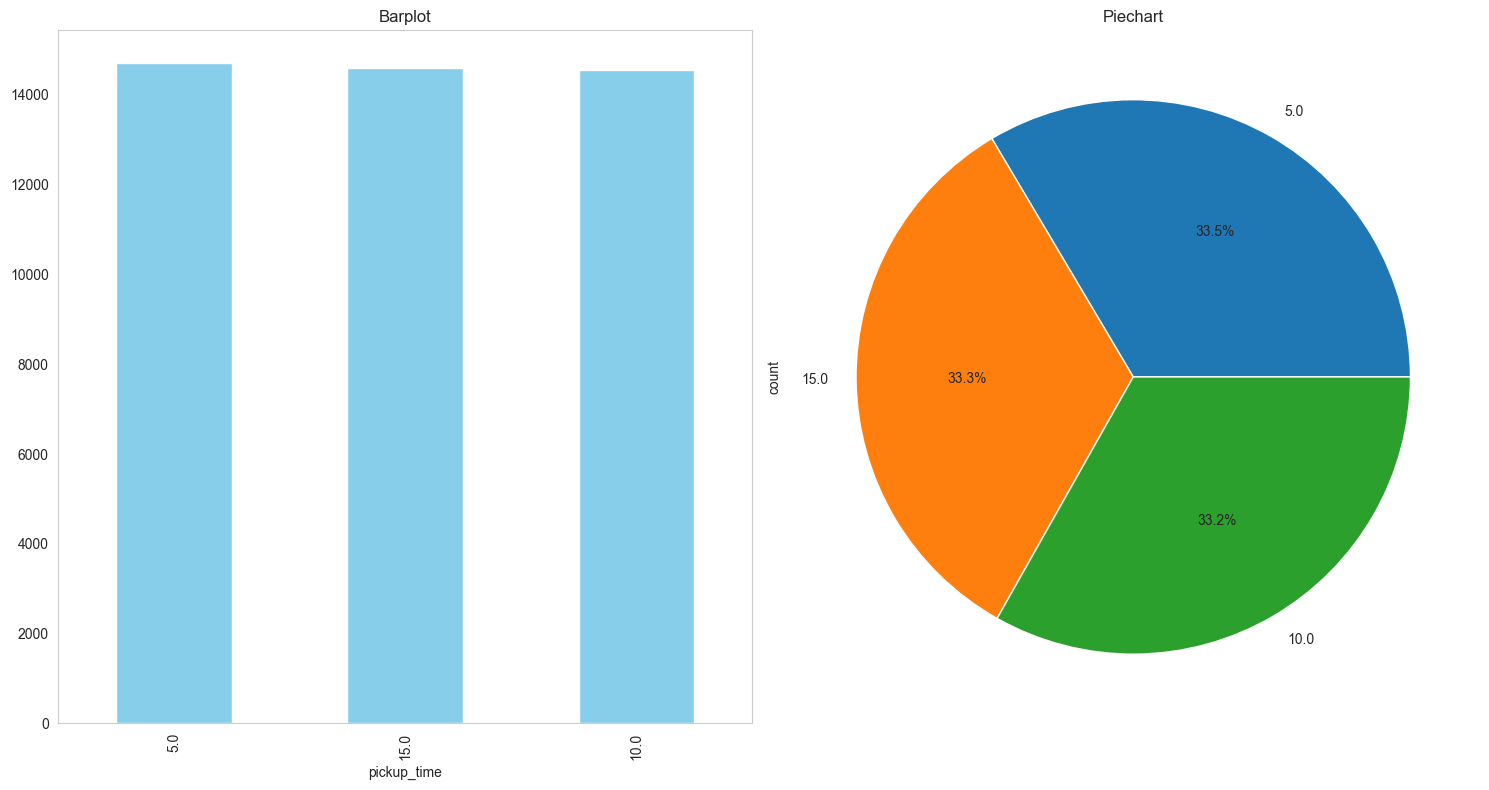

In [38]:
uni_cat('pickup_time')

p_value : 0.1882 

There is no significant difference between the means of the groups 



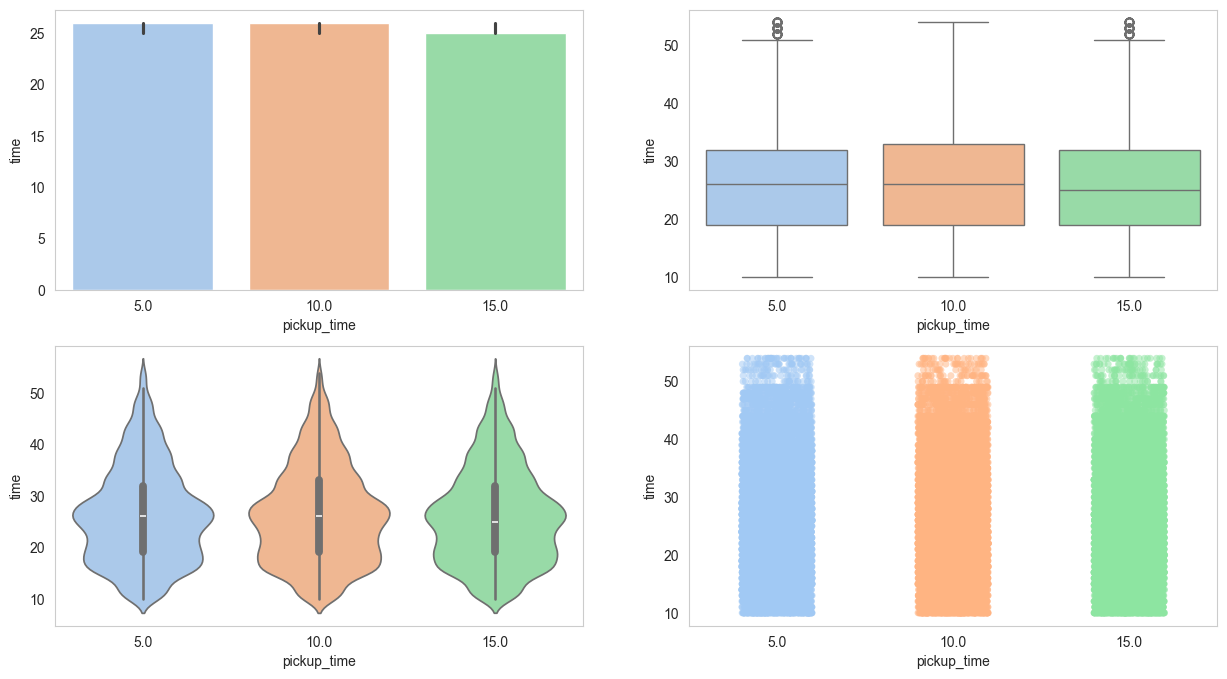

In [39]:
num_cat('time','pickup_time')

(1) Order Pickup time doesn't has any visible and statistical impact on the delivery time.

There are 2 unique values in is_weekend column 

There are 0.0% missing values in is_weekend column 

is_weekend
0    0.74522
1    0.25478
Name: proportion, dtype: float64 



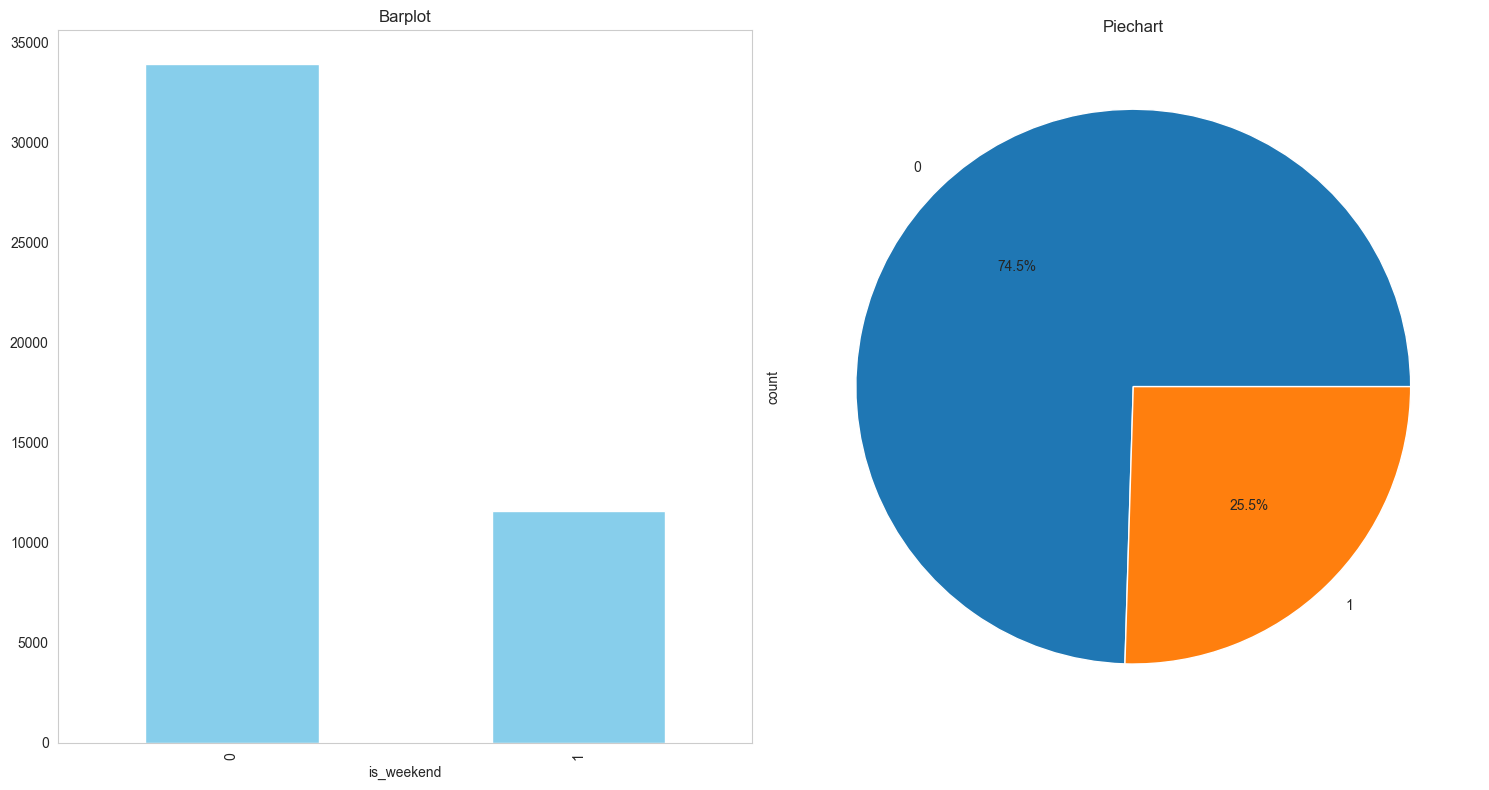

In [40]:
uni_cat('is_weekend')

p_value : 0.0000 

There is a significant difference between the means of the groups 



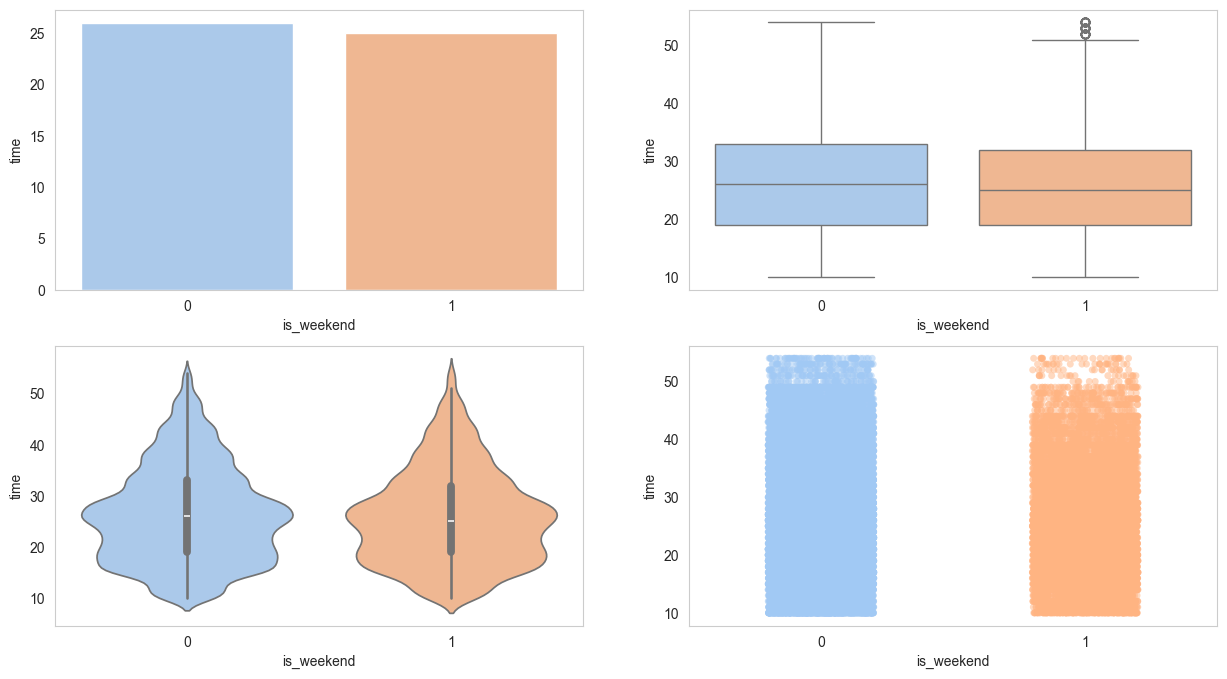

In [41]:
num_cat('time','is_weekend')

(1) Median delivery time is slightly lower in weekend with simillar distribution with weekdays.

There are 4 unique values in time_of_day column 

There are 5.0% missing values in time_of_day column 

time_of_day
evening           0.421348
night             0.209224
morning           0.198241
afternoon         0.171187
after_midnight    0.000000
Name: proportion, dtype: float64 



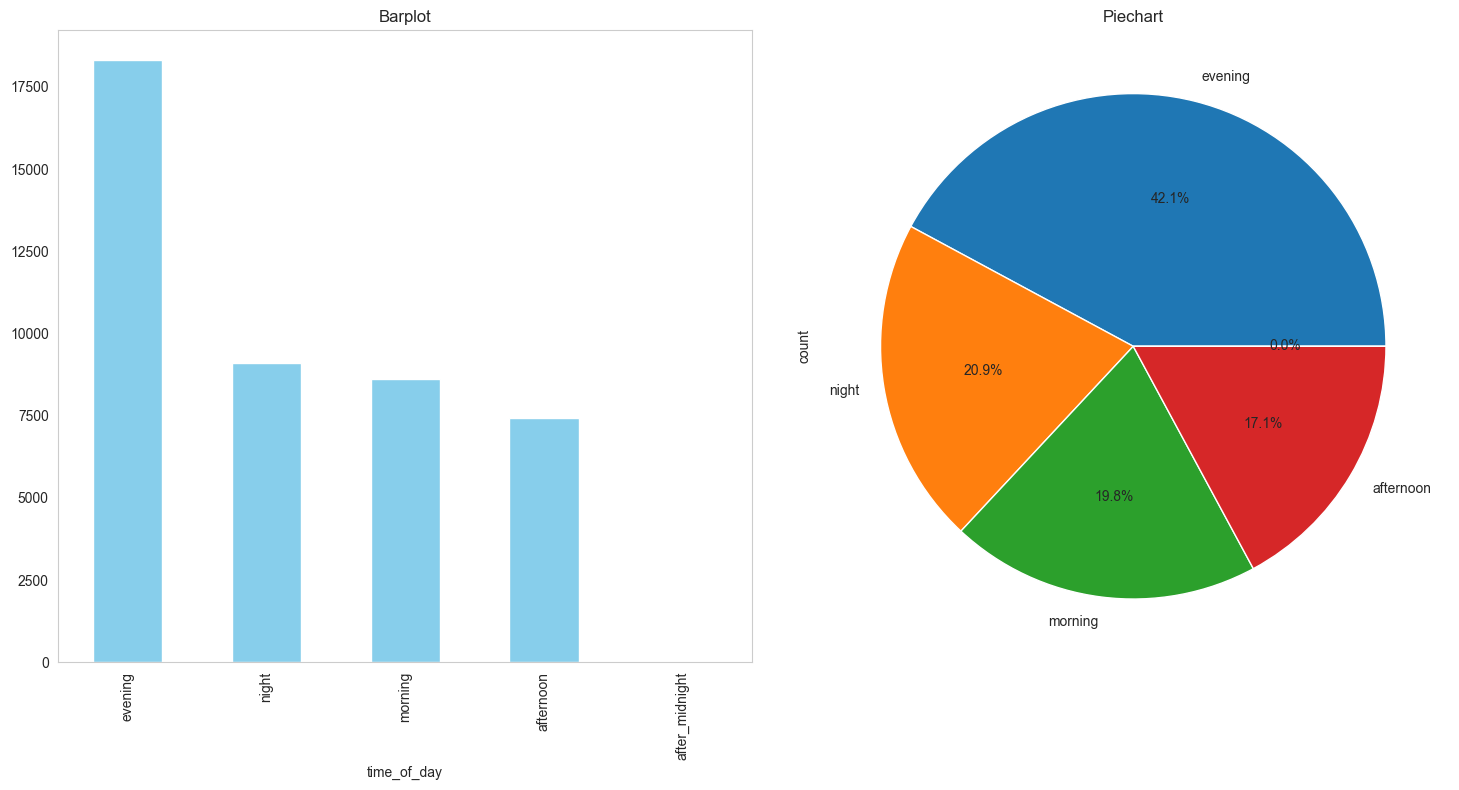

In [42]:
uni_cat('time_of_day')

p_value : 0.0000 

There is a significant difference between the means of the groups 



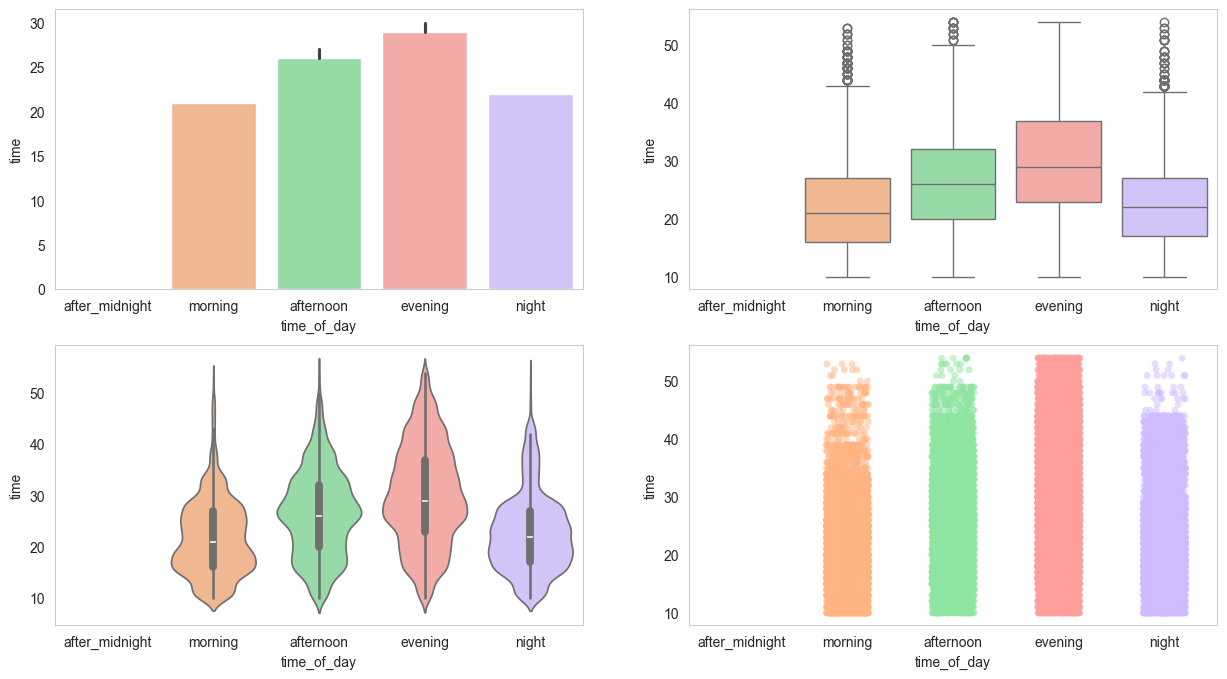

In [43]:
num_cat('time','time_of_day')

(1) Most Numbers of orders are during the evening with highest median delivery time of 28-29 minutes.  
(2) Lowest Median delivery time is during the morning with 20-21 minutes.

# Multivariate Analysis

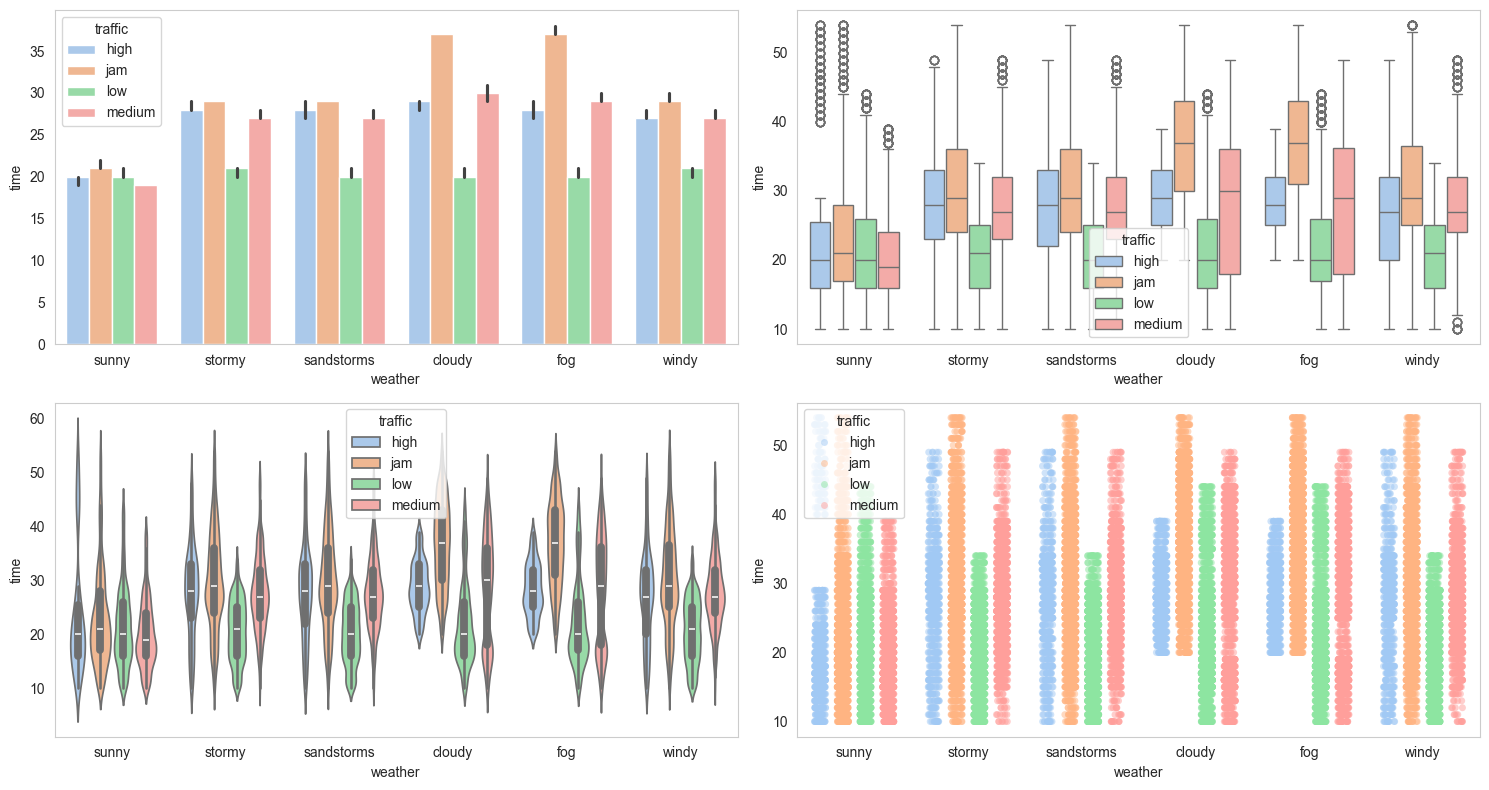

In [45]:
multivariate_analysis('time','weather','traffic')


(1) There are some extreme delivery time when it's sunny and traffic is heavy.  
(2) Regardless of the traffic the delivery time is lower for sunny weather.  
(3) Regardless of the weather the median delivery time is simillar at close to 20 minutes for low traffic. 

In [53]:
cleaned_df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_lat', 'restaurant_long',
       'delivery_lat', 'delivery_long', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle_type',
       'multiple_deliveries', 'festival', 'city_type', 'time', 'city_name',
       'distance_km', 'day', 'month', 'day_of_week', 'is_weekend',
       'pickup_time', 'order_time_hour', 'time_of_day'],
      dtype='object')

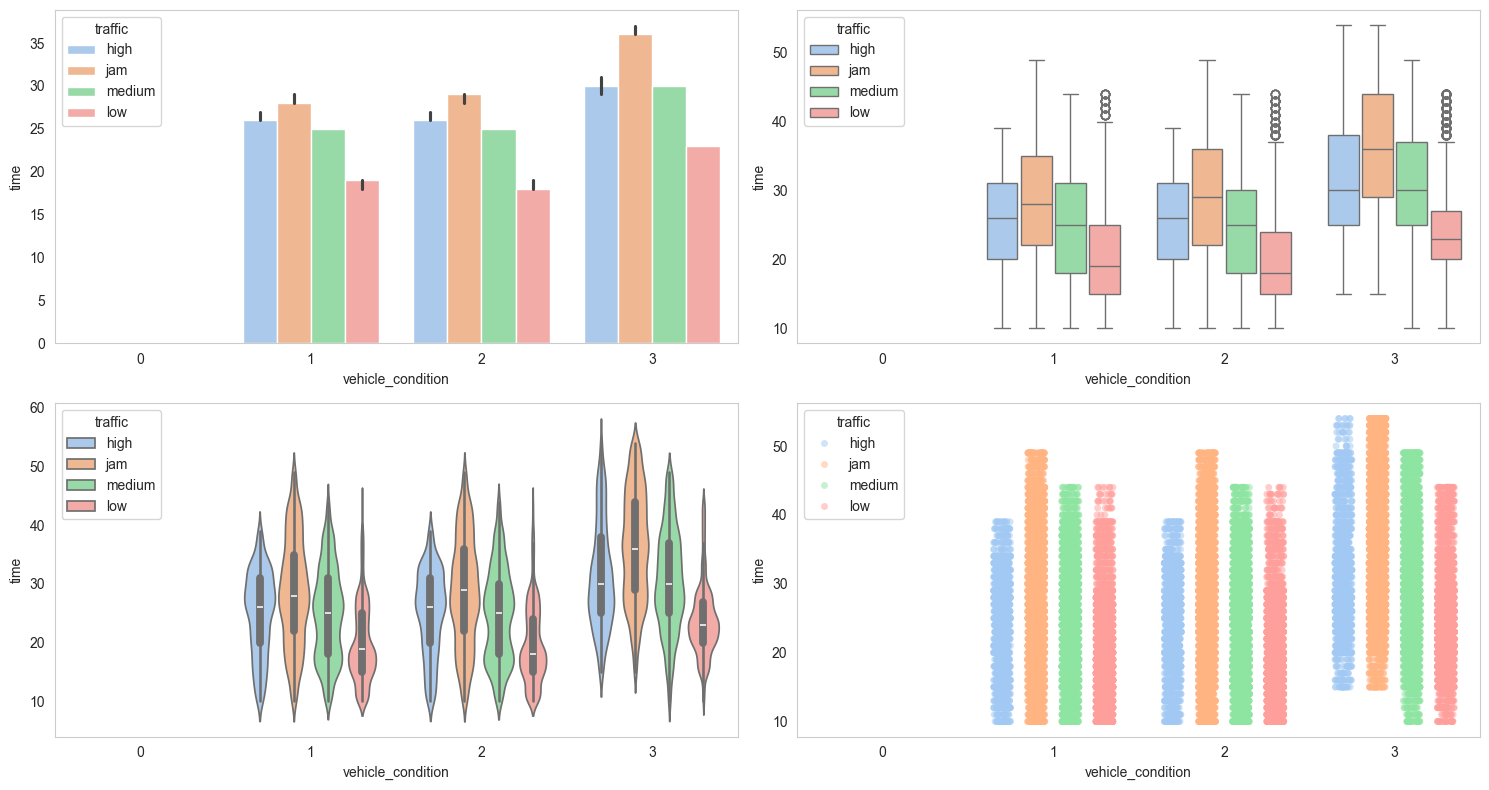

In [54]:
multivariate_analysis('time','vehicle_condition','traffic')

(1) Vehicle Condition 3 has higher median delivery time regardless of the traffic.

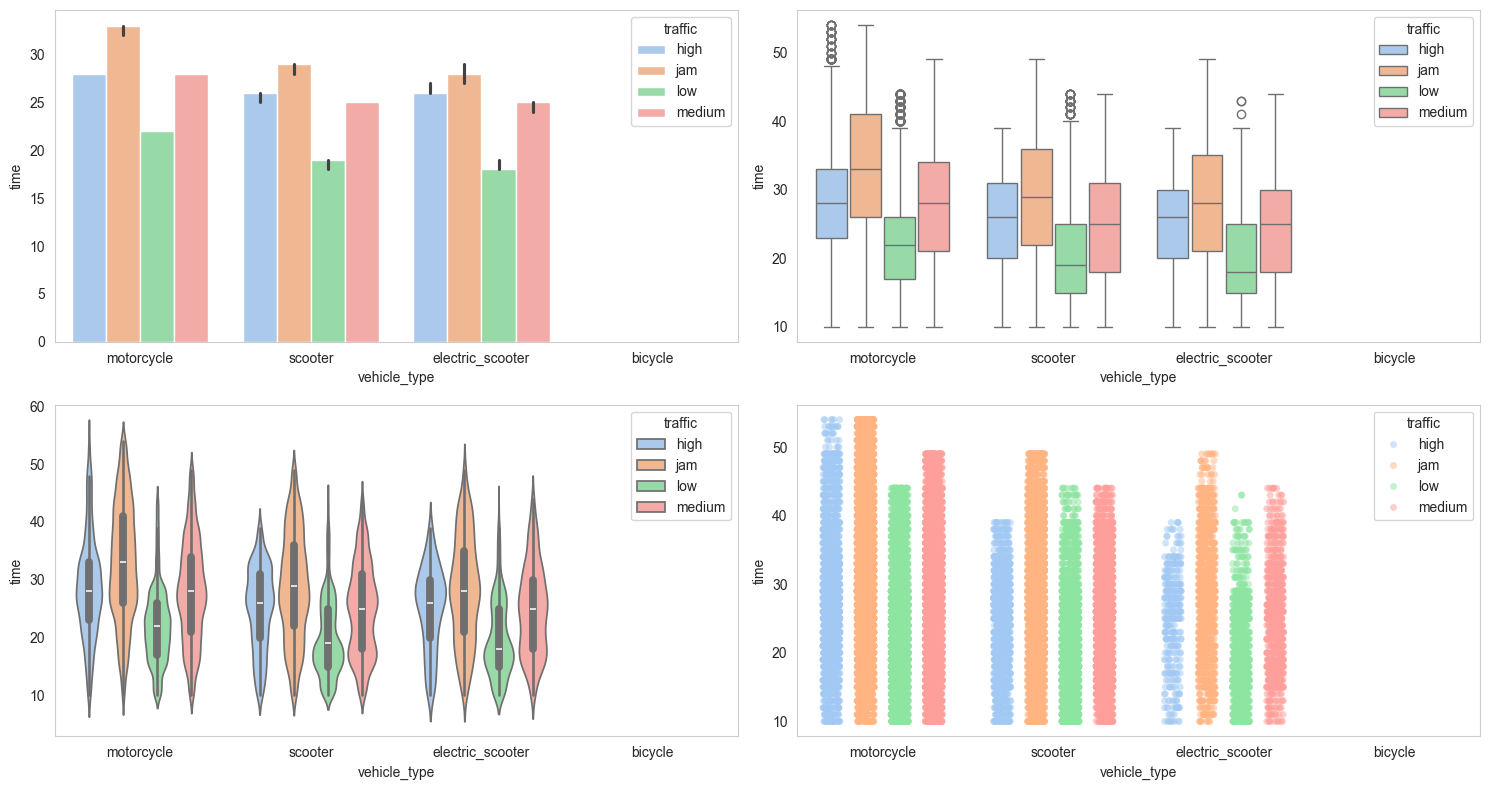

In [56]:
multivariate_analysis('time','vehicle_type','traffic')

(1) Electric Scooter has the lowest Median delivery time regardless of the traffic with less outliers.  
(2) Motorcycle has the highest median delivery time regardless of the traffic with more outliers.

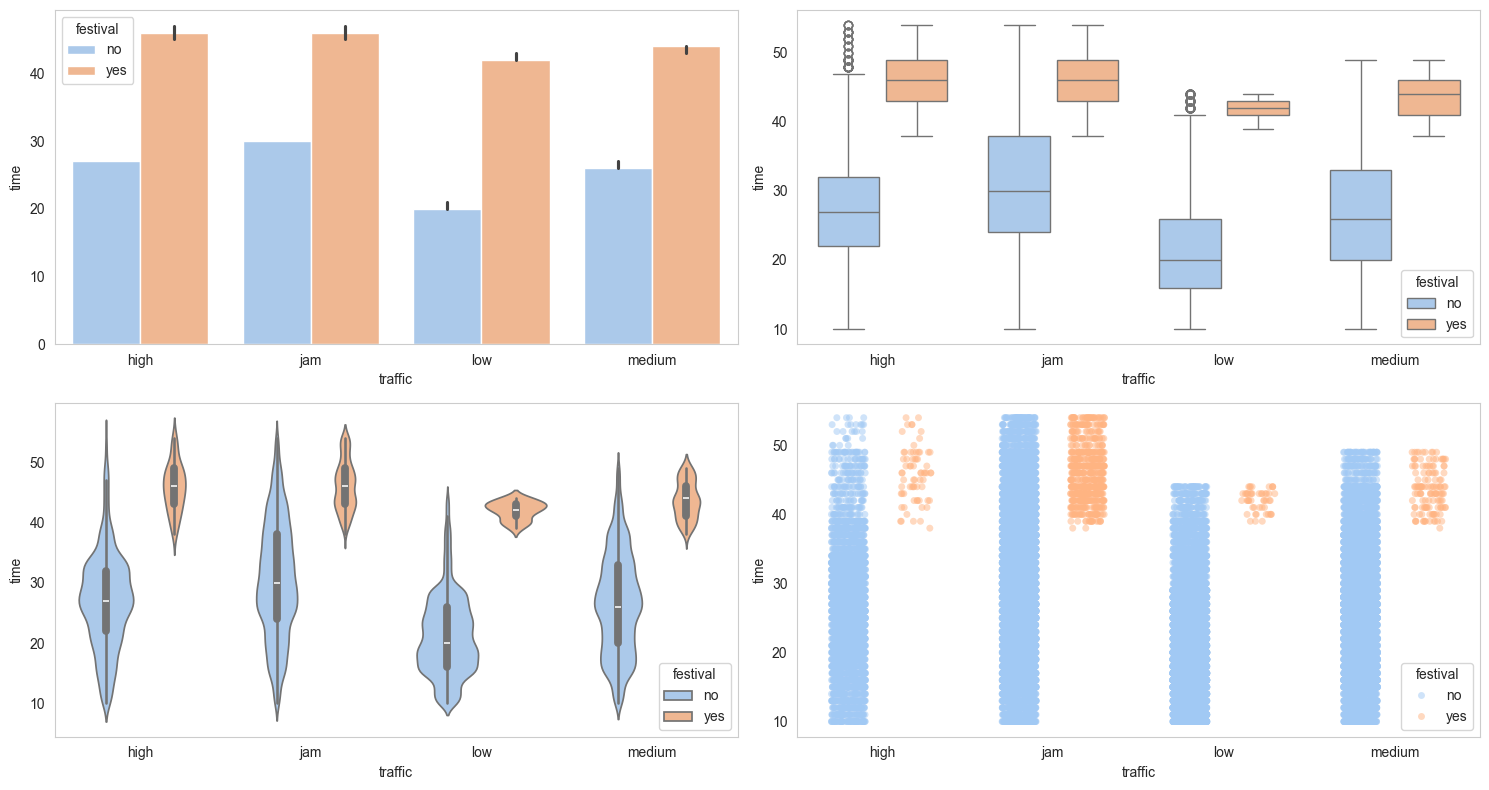

In [59]:
multivariate_analysis('time','traffic','festival')

(1) Regardless of the traffic the delivery time is higher during festivals.  
But there are so less data for festivals.  
(2) There is more traffic jam on festival days.

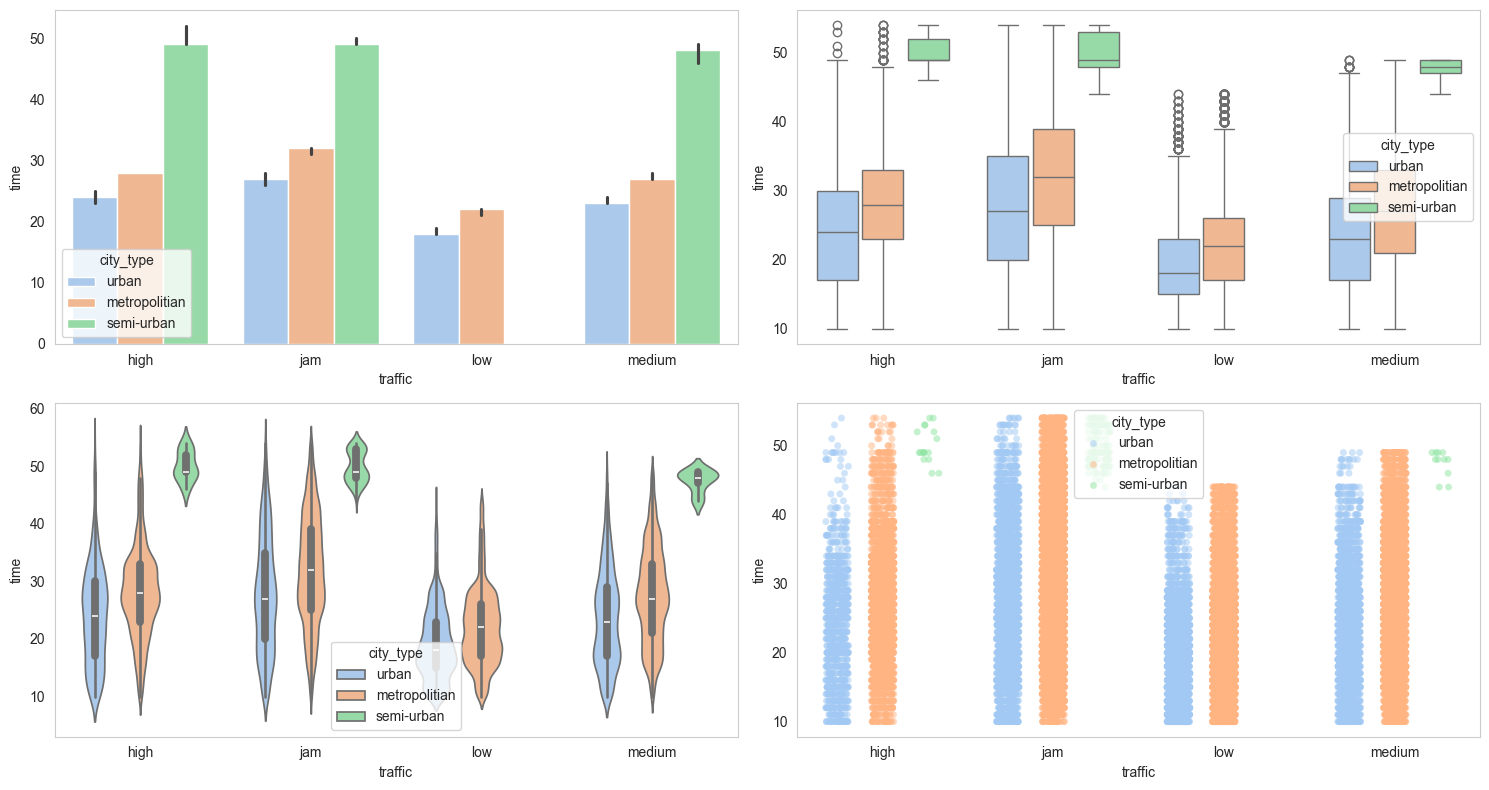

In [61]:
multivariate_analysis('time','traffic','city_type')

(1) Simillar distribution of median delivery time for all cities regardless of the traffic.  
(2) low traffic has high variance right skewed and more outliers.

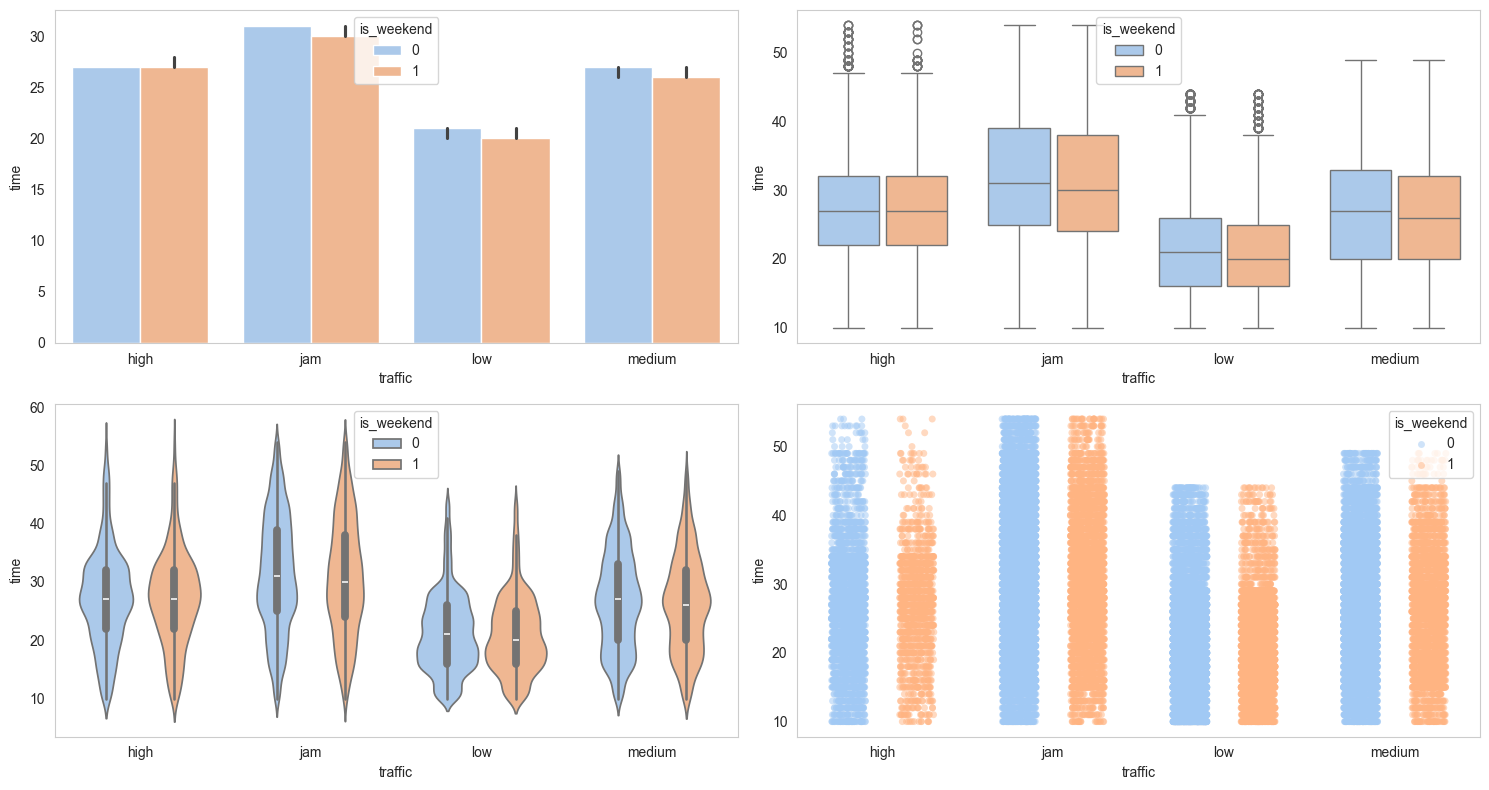

In [62]:
multivariate_analysis('time','traffic','is_weekend')

(1) Regardless of the weekend the median delivery time is simillar for all traffic situations.

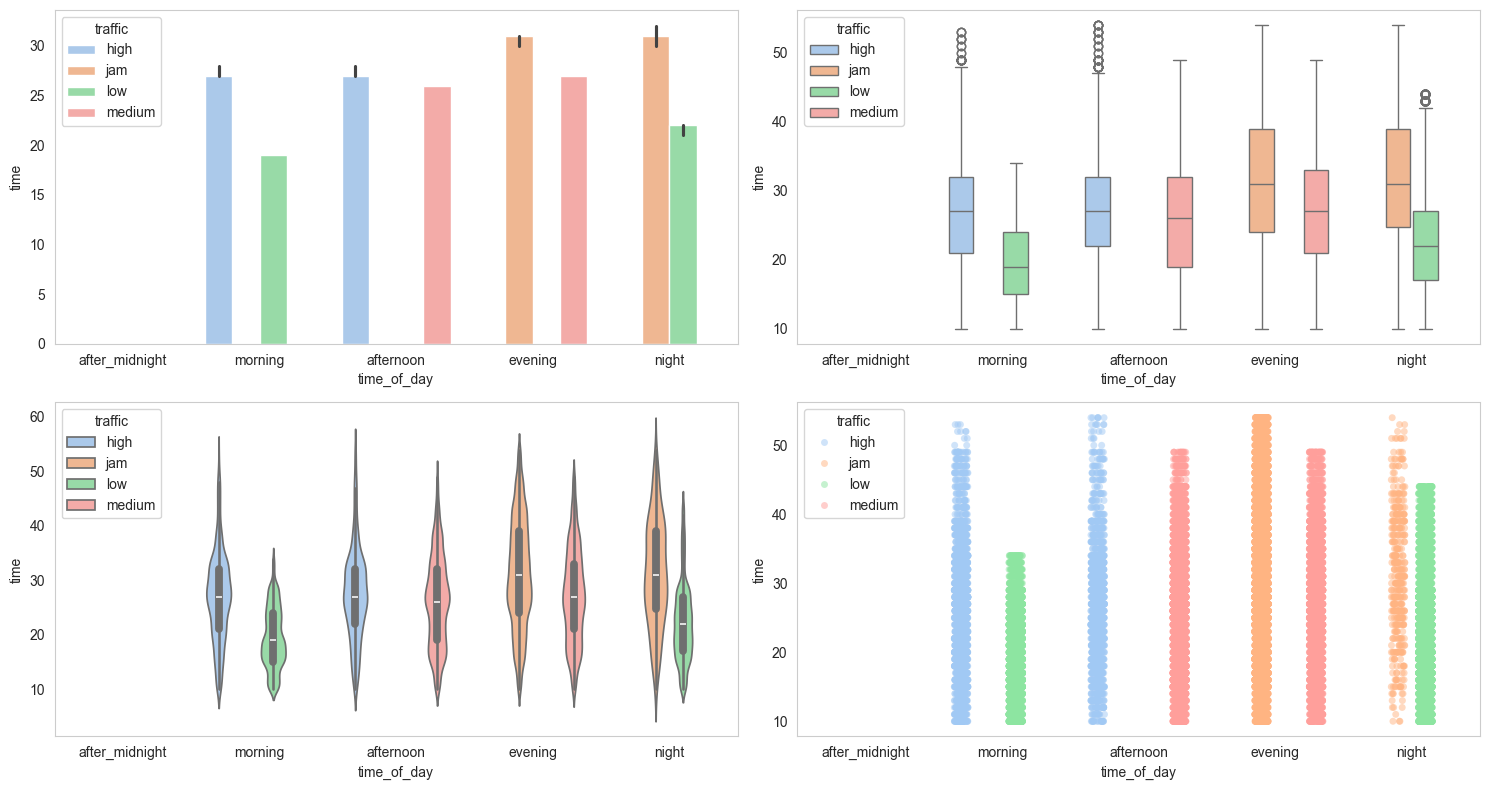

In [64]:
multivariate_analysis('time','time_of_day','traffic')

(1) Not enough data for all time of day.  
(2) traffic is lowest in the morning with the lowest median delivary time of 20-21 minutes.  
(3) traffic is highest in the evening with the highest median delivary time of 30 minutes.